In [1]:
import os
import scipy.io
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path
notebook_path = Path(sys.argv[0]).parent if "ipykernel" in sys.argv[0] else Path.cwd()
sys.path.append(str(notebook_path))
from utils import use  
from utils import make_data as mkdata
from utils import feature
from utils import classical_ml as cm
from utils import dbn_model as dbnm

In [2]:
# ===================== 主函数====================
def main_bearing_fault_diagnosis(
    pickle_path,
    save_dir,
    csv_save_dir,
    result_path,
    result_fig_path,
    window_size,
    step_size,
    config
):
    """
    主函数：轴承故障诊断完整流程（完全保留原始逻辑）
    参数：所有外部配置参数（与上面的外部配置一一对应）
    """
    # 确保保存目录存在（不改动你的核心逻辑，仅增加目录创建避免报错）
    for dir_path in [save_dir, csv_save_dir, result_path, result_fig_path]:
        os.makedirs(dir_path, exist_ok=True)
    
    # 1.读入原始数据，保存为npz数据集================================
    df = pd.read_pickle(pickle_path)

    # 对工况信息进行筛选
    filtered_df, cond_name = mkdata.filter_conditions(df, config)

    # 滑动窗口采样
    expanded_df = mkdata.expand_df_with_sliding_windows(filtered_df,
                                                 window_size=window_size,
                                                 step_size=step_size) 
    # 故障标签编码
    expanded_df, unique_labels = mkdata.get_fault_label(expanded_df, '故障标签', is_print=False)

    out_path = mkdata.save_npz_data(expanded_df, unique_labels, cond_name, window_size, step_size, save_dir)

    # 二、提取特征,保存为csv数据集====================================
    # 对采样频率为12k的提取特征
    fs = int(config['sampling_rates'][0]) * 1000
    print(fs)
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(out_path)
    feature_df = feature.extract_all_features_batch_extended(X, fs=fs,
                                            use_envelope=True,
                                            use_cwt=False,
                                            use_stft=True)  

    feature_df["label"] = y
    feature_df["sorce"] = ids

    core_name = out_path.split('\\')[-1].replace('.npz', '.csv')
    feature_df.to_csv(os.path.join(csv_save_dir, core_name), index=False)
    print('csv文件已保存为',core_name)

    # 三、跑简单模型的结果，保存结果和简单图像=========================
    feature_csv_path = os.path.join(csv_save_dir, core_name)
    feature_df = pd.read_csv(feature_csv_path)

    results_all = cm.run_baseline_experiments(
        feature_df, 
        label_col="label", 
        sorce_col="sorce",  # 新加入的字段
        stratify=False  # 如果需要根据 sorce 列分层划分
    )

    results_all_fc = cm.run_baseline_experiments(
        feature_df, 
        label_col="label", 
        sorce_col="sorce",  # 新加入的字段
        stratify=True  # 如果需要根据 sorce 列分层划分
    )

    #四、跑DBN模型，更新实验结果======================================
    dbn_res_all, (tl, ta, tsa) = dbnm.run_dbn_experiment(feature_df,
                       label_col="label",
                       sorce_col='sorce',
                       stratify=False,
                       test_size=0.2,
                       random_state=0,
                       n_pretrain_epochs=50,
                       n_finetune_epochs=300,
                       lr=1e-3,
                       device=None)
    results_all.update(dbn_res_all)
    dbnm.plot_dbn_curves(tl, ta, tsa, os.path.join(result_fig_path, f'{core_name[:-4]}_dbn_all_feature_training.png'))

    dbn_res_all_fc, (tl, ta, tsa) = dbnm.run_dbn_experiment(feature_df,
                       label_col="label",
                       sorce_col='sorce',
                       stratify=True,
                       test_size=0.2,
                       random_state=0,
                       n_pretrain_epochs=80,
                       n_finetune_epochs=300,
                       lr=1e-3,
                       device=None)
    results_all_fc.update(dbn_res_all_fc)
    dbnm.plot_dbn_curves(tl, ta, tsa, os.path.join(result_fig_path, f'{core_name[:-4]}_dbn_all_feature_fc_training.png'))
    
    
    #整合结果
    results_sum = {
        "all_feature": results_all,
        "all_feature_fc": results_all_fc
    }

    
    df_env_scores = cm.results_env_to_dataframe(results_sum)


    result_prefix = core_name[:-4]
    max_idx = 0
    for f in os.listdir(result_path):
        if f.startswith(f"{result_prefix}_result") and f.endswith('.pkl'):
            idx_str = f[len(f"{result_prefix}_result"):-4]
            if idx_str.isdigit():
                max_idx = max(max_idx, int(idx_str))
    result_filename = f"{result_prefix}_result{max_idx + 1}.pkl"
    
    #5.可是化部分
    cm.save_all_result_df(df_env_scores, os.path.join(result_path, result_filename))

    cm.plot_models_for_env(df_env_scores, env="all_feature",
                        metrics=("accuracy", "f1_macro"),
                        save_path=os.path.join(result_fig_path, f'{core_name[:-4]}_env_all_feature_models.png')
                        )

    cm.plot_models_for_env(df_env_scores, env="all_feature_fc",
                        metrics=("accuracy", "f1_macro")
                        , save_path=os.path.join(result_fig_path, f'{core_name[:-4]}_env_all_feature_fc_models.png')
                        )
    
    



筛选后样本数： 112
条件名称： cond_sampling_rates_48_sampling_positions_DE-BA-FE_loads_0-1-2-3
X shape: (21314, 2048)
y shape: (21314,)
npz 文件已保存到: E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_48_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz
48000
(21314, 2048) (21314,) (21314,)
['B007' 'B014' 'B021' 'IR007' 'IR014' 'IR021' 'Normal' 'OR007' 'OR014'
 'OR021']
csv文件已保存为 cond_sampling_rates_48_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv
训练集大小: 17051, 测试集大小: 4263
特征维度: 40

训练模型: LogReg


d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg - Accuracy: 0.8998, F1_macro: 0.8652
分类报告:
              precision    recall  f1-score   support

           0     0.7508    0.7928    0.7712       304
           1     0.7591    0.6865    0.7210       303
           2     0.8161    0.7774    0.7963       274
           3     0.9967    1.0000    0.9983       300
           4     0.7960    0.7453    0.7698       267
           5     0.9148    0.8430    0.8774       293
           6     0.9944    0.9981    0.9963       535
           7     0.9395    0.9778    0.9583       857
           8     0.7670    0.8229    0.7940       288
           9     0.9658    0.9727    0.9692       842

    accuracy                         0.8998      4263
   macro avg     0.8700    0.8616    0.8652      4263
weighted avg     0.8991    0.8998    0.8989      4263

混淆矩阵:
[[241   8   6   0   1   0   0   2  46   0]
 [ 26 208   5   0  26   0   3   5  10  20]
 [  2   2 213   0  14  13   0  17  12   1]
 [  0   0   0 300   0   0   0   0   0   0]
 [ 10  41  11

Exception in thread Thread-144 (_readerthread):
Traceback (most recent call last):
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\anaconda\envs\pikaqiu\Lib\site-packages\ipykernel\ipkernel.py", line 788, in run_closure
    _threading_Thread_run(self)
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anaconda\envs\pikaqiu\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


KNN_5 - Accuracy: 0.9322, F1_macro: 0.9116
分类报告:
              precision    recall  f1-score   support

           0     0.8203    0.8257    0.8230       304
           1     0.8586    0.8614    0.8600       303
           2     0.9084    0.8321    0.8686       274
           3     0.9901    1.0000    0.9950       300
           4     0.9050    0.8202    0.8605       267
           5     0.9571    0.9898    0.9732       293
           6     0.9981    0.9981    0.9981       535
           7     0.9545    0.9790    0.9666       857
           8     0.7879    0.8125    0.8000       288
           9     0.9703    0.9715    0.9709       842

    accuracy                         0.9322      4263
   macro avg     0.9150    0.9090    0.9116      4263
weighted avg     0.9321    0.9322    0.9318      4263

混淆矩阵:
[[251   3   0   0   0   0   0   0  50   0]
 [  2 261   7   0  13   0   0   9   0  11]
 [  3   8 228   0   6   8   0  13   6   2]
 [  0   0   0 300   0   0   0   0   0   0]
 [  2  23  10 

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

LightGBM - Accuracy: 0.7988, F1_macro: 0.5009
分类报告:
              precision    recall  f1-score   support

           0     0.8453    0.7930    0.8183       372
           1     0.4252    0.3441    0.3804       372
           2     0.9871    0.4126    0.5820       744
           4     0.0000    0.0000    0.0000         0
           5     0.0000    0.0000    0.0000         0
           6     0.0000    0.0000    0.0000         0
           7     0.8870    0.9991    0.9397      1116
           8     0.7667    0.8656    0.8131       372
           9     0.9969    0.9525    0.9742      1368

    accuracy                         0.7988      4344
   macro avg     0.5454    0.4852    0.5009      4344
weighted avg     0.8854    0.7988    0.8202      4344

混淆矩阵:
[[ 295   12    1    7    0    0    0   56    1]
 [  10  128    0  178    0    0   26   30    0]
 [   0  120  307  182   23    1  108    0    3]
 [   0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  Epoch 1/50, recon loss = 0.255903
  Epoch 2/50, recon loss = 0.173036
  Epoch 3/50, recon loss = 0.156012
  Epoch 4/50, recon loss = 0.150689
  Epoch 5/50, recon loss = 0.148399
  Epoch 6/50, recon loss = 0.146532
  Epoch 7/50, recon loss = 0.146641
  Epoch 8/50, recon loss = 0.146065
  Epoch 9/50, recon loss = 0.145560
  Epoch 10/50, recon loss = 0.145586
  Epoch 11/50, recon loss = 0.145802
  Epoch 12/50, recon loss = 0.145290
  Epoch 13/50, recon loss = 0.145054
  Epoch 14/50, recon loss = 0.145392
  Epoch 15/50, recon loss = 0.145141
  Epoch 16/50, recon loss = 0.145257
  Epoch 17/50, recon loss = 0.145635
  Epoch 18/50, recon loss = 0.145508
  Epoch 19/50, recon loss = 0.145396
  Epoch 20/50, recon loss = 0.145257
  Epoch 21/50, recon loss = 0.144956
  Epoch 22/50, recon loss = 0.144925
  Epoch 23/50, recon loss = 0.145676
  Epoch 24/50, recon loss = 0.145584
  Epoch 25/50, recon loss = 0.145199
  Epoch 26/50, recon loss = 0.145489
  Epoch 27/50, recon loss = 0.145383
  Epoch 28

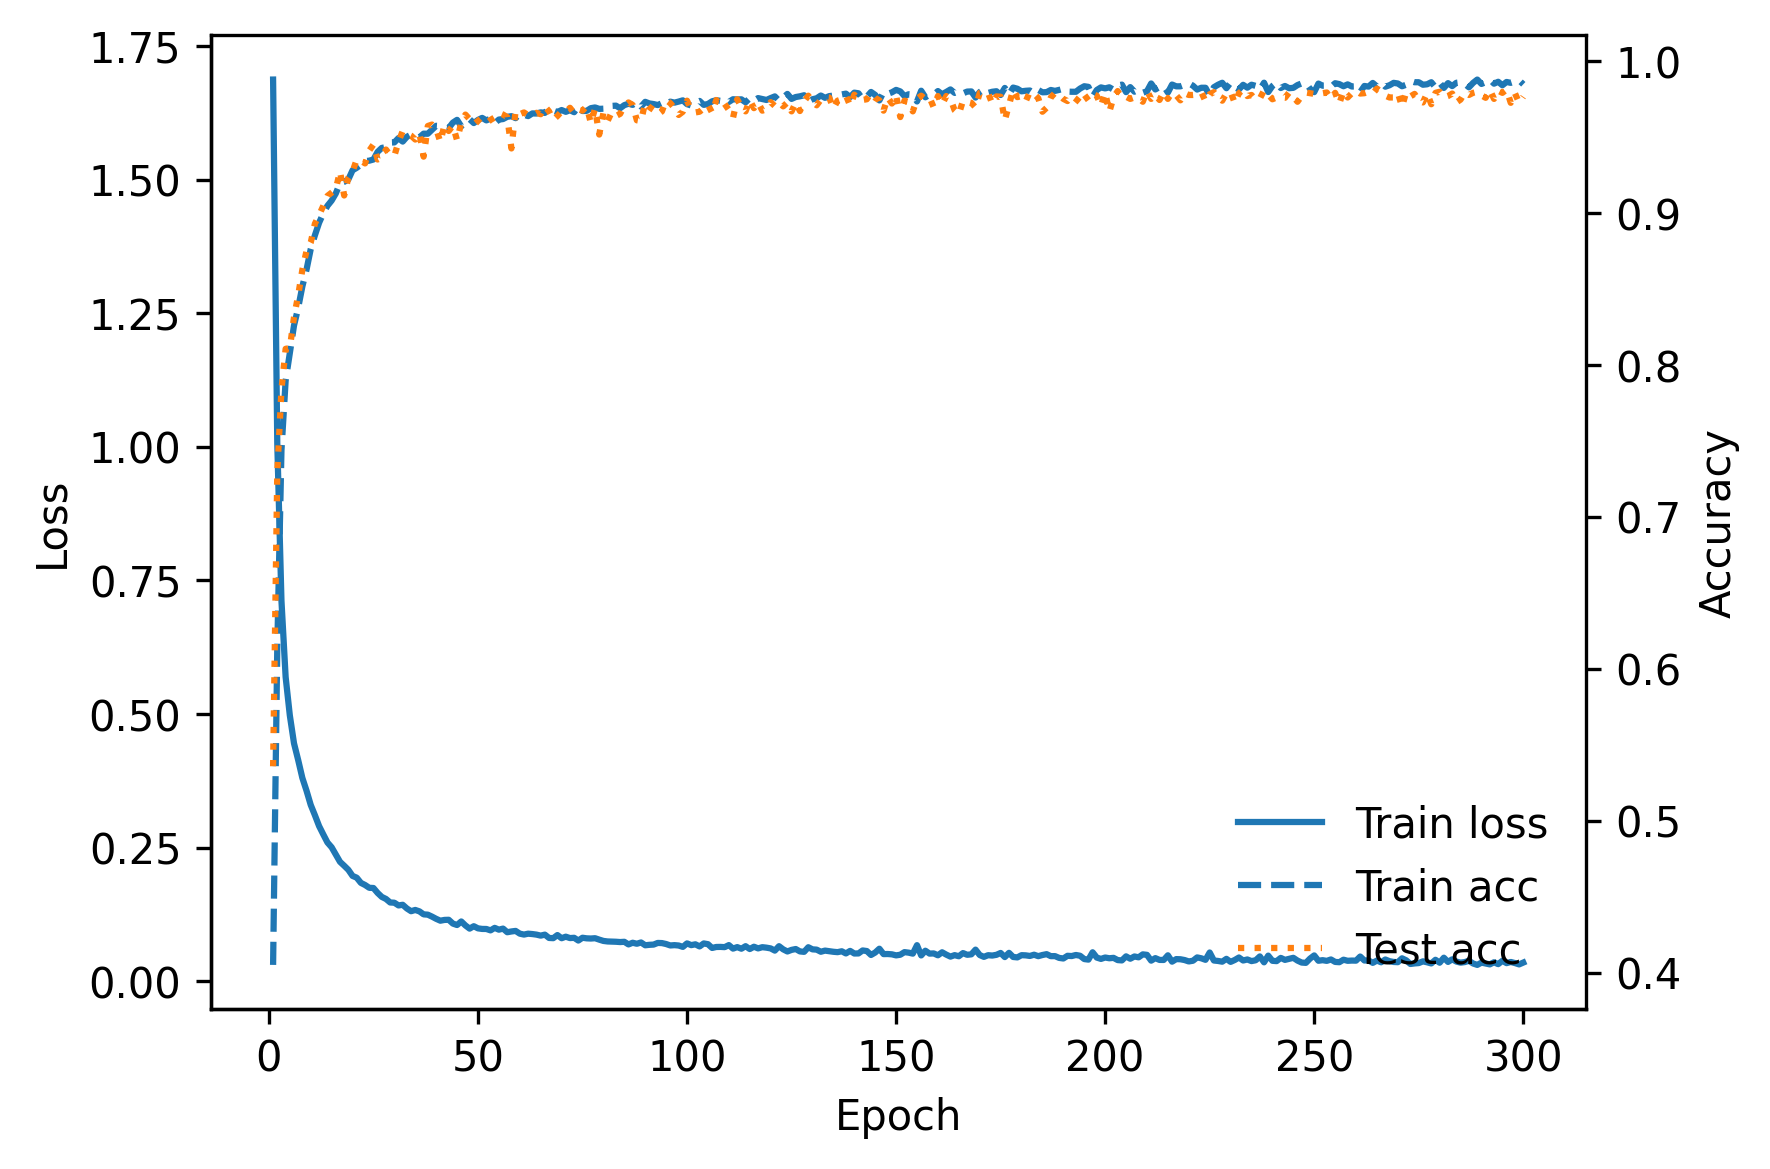

训练集样本： ['X201' 'X215' 'X204' 'X251' 'X162' 'X192' 'X111' 'X138' 'X241' 'X252'
 'X176' 'X097' 'X240' 'X112' 'X190' 'X202' 'X173' 'X099' 'X213' 'X250'
 'X226' 'X110' 'X136' 'X175' 'X263' 'X100' 'X163' 'X123' 'X109' 'X264'
 'X135' 'X191' 'X217' 'X161' 'X214' 'X177' 'X227' 'X164' 'X253' 'X125'
 'X122' 'X098' 'X151' 'X148']
测试集样本： ['X149' 'X239' 'X262' 'X137' 'X229' 'X124' 'X238' 'X265' 'X150' 'X203'
 'X189' 'X228']
训练集大小: 16970, 测试集大小: 4344
特征维度: 40
X_train: (16970, 40)
y_train: (16970,)
X_test : (4344, 40)
y_test : (4344,)
DBN input_dim = 40 , n_classes = 10
Pretraining RBM layer 1/2
  Epoch 1/80, recon loss = 0.255576
  Epoch 2/80, recon loss = 0.172042
  Epoch 3/80, recon loss = 0.155011
  Epoch 4/80, recon loss = 0.148918
  Epoch 5/80, recon loss = 0.146117
  Epoch 6/80, recon loss = 0.145708
  Epoch 7/80, recon loss = 0.145024
  Epoch 8/80, recon loss = 0.144630
  Epoch 9/80, recon loss = 0.144964
  Epoch 10/80, recon loss = 0.143532
  Epoch 11/80, recon loss = 0.143674
  Epoch 12/80,

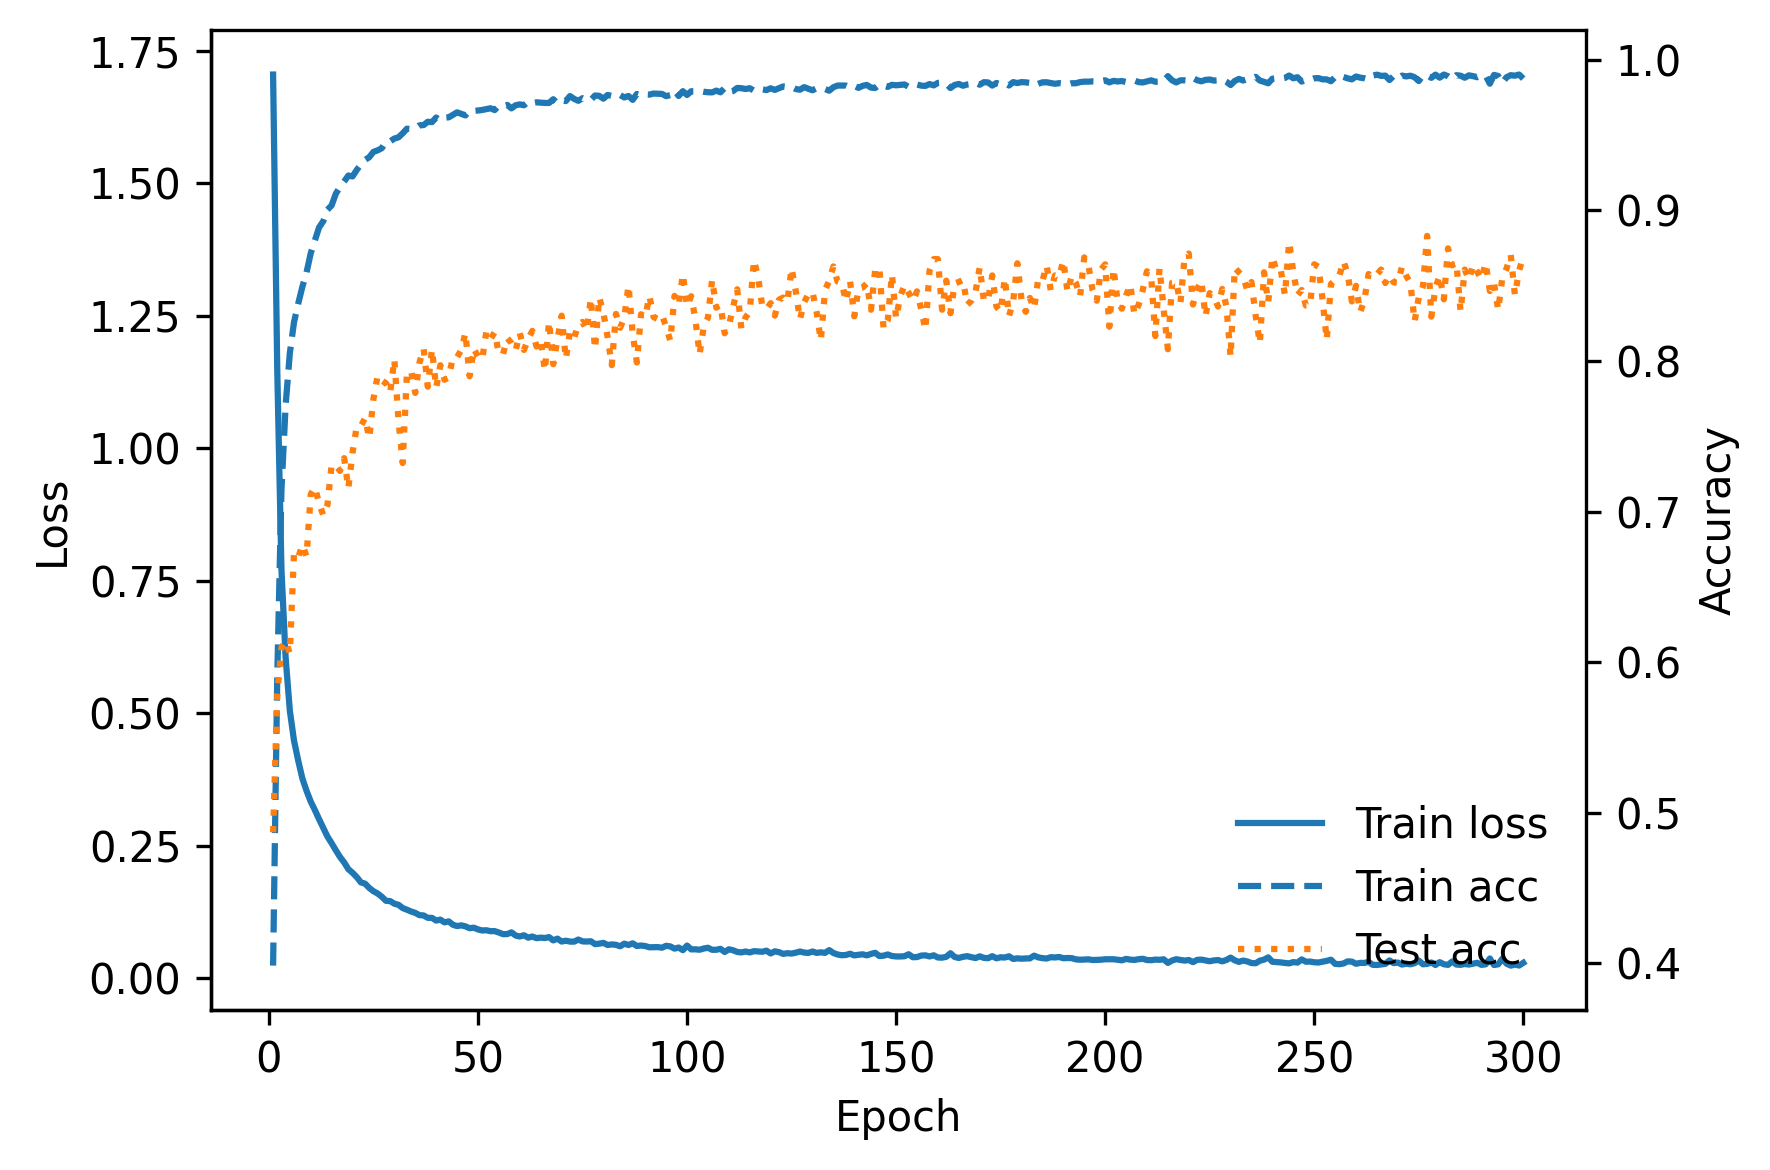

[save_results_df] 结果已保存到：E:\故障诊断2\实验整理\result\df\cond_sampling_rates_48_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_result1.pkl
[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_48_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_env_all_feature_models.png


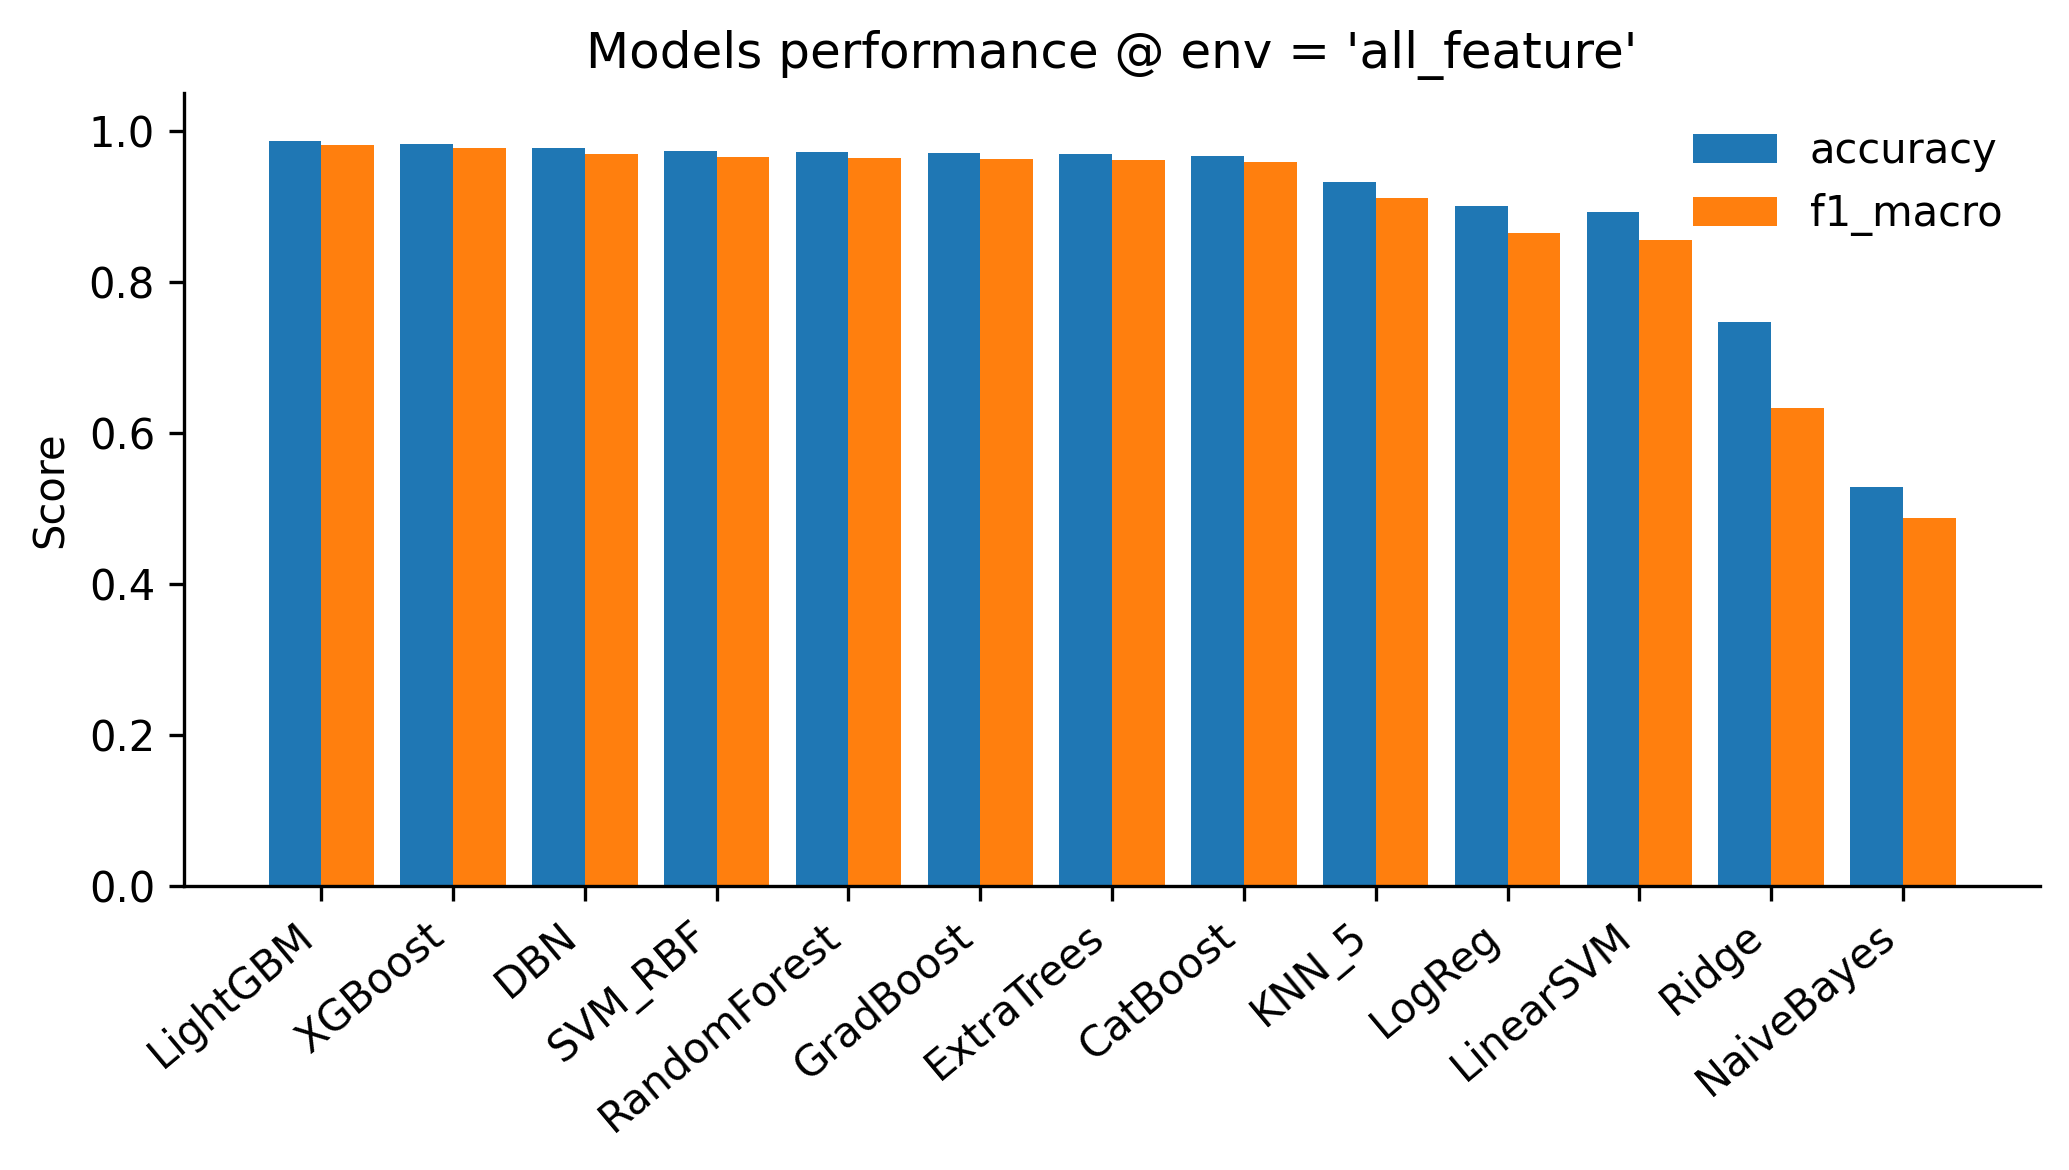

[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_48_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_env_all_feature_fc_models.png


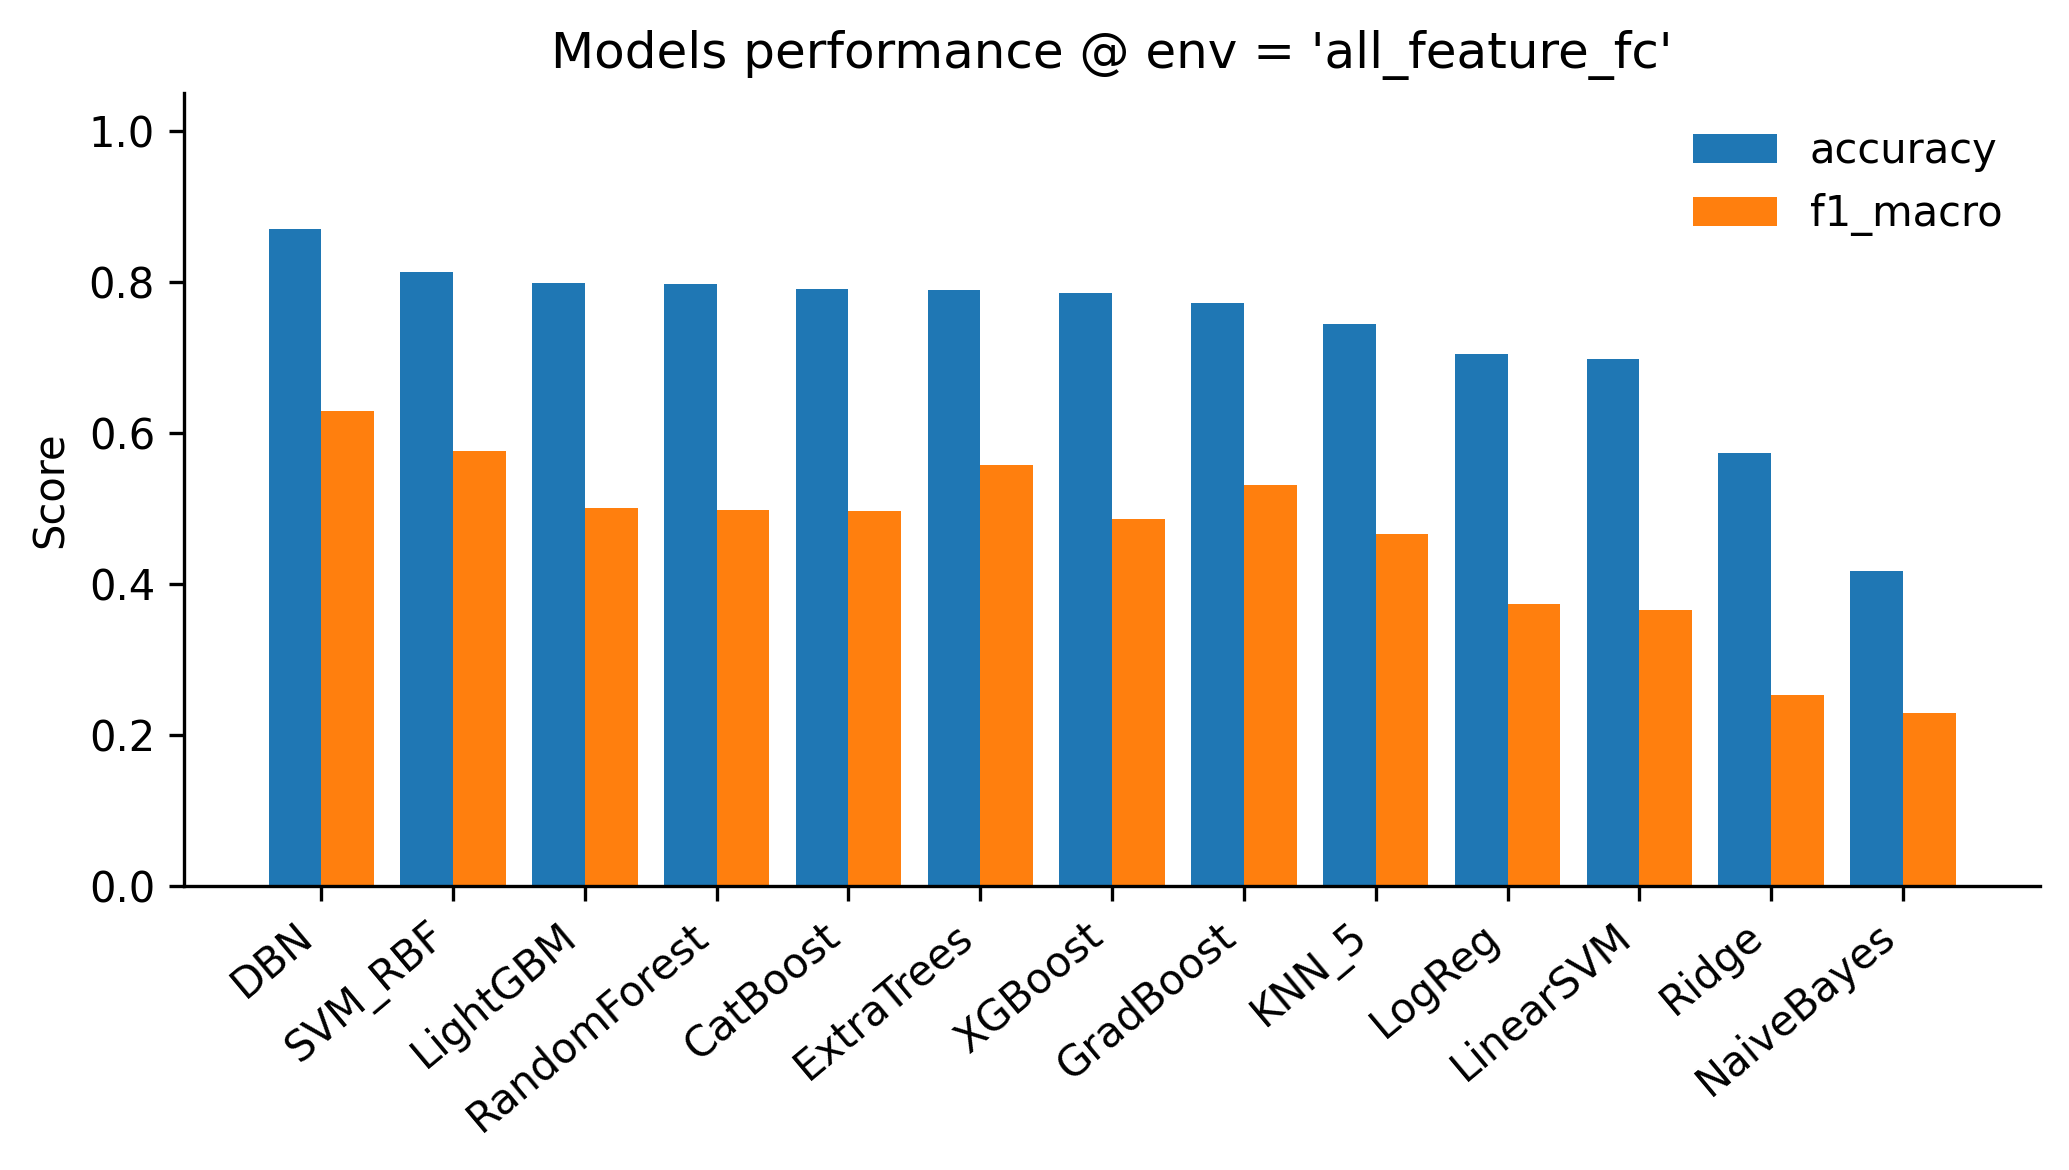

=== 全流程执行完成 ===


In [5]:
CONFIG = {
    "sampling_rates": ['48'],       # None 或 [] 表示不筛选;12,48,好像只能单独选一个
    "sampling_positions": ["DE",'BA','FE'],    
    "bearing_positions": None,       #['FE', 'DE', 'Normal']
    "loads": ['0', '1', '2','3'],    #载荷大小     
    "rpms": None,                    # 不筛选转速
    "fault_types": None,             # 不筛选故障类型
    "or_positons": []                # [None, 'Centered', 'Opposite', 'Orthogonal']
}
#设定数据分区方式
WINDOW_SIZE = 2048
STEP_SIZE = 1024

#保存路径
SAVE_DIR = r'E:\故障诊断2\实验整理\dataset\processed\npz'
CSV_SAVE_DIR =  r'E:\故障诊断2\实验整理\dataset\processed\csv'

RESULT_PATH = r'E:\故障诊断2\实验整理\result\df'
RESULT_PATH_FIG = r'E:\故障诊断2\实验整理\result\figs'

if __name__ == "__main__":
    main_bearing_fault_diagnosis(
        pickle_path='E:\故障诊断2\实验整理\dataset\processed\CWRU_bearing_dataset.pkl',
        save_dir=SAVE_DIR,
        csv_save_dir=CSV_SAVE_DIR,
        result_path=RESULT_PATH,
        result_fig_path=RESULT_PATH_FIG,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE,
        config=CONFIG
    )
    print("=== 全流程执行完成 ===")

In [ ]:
df = pd.read_pickle(os.path.join(RESULT_PATH, f'{core_name[:-4]}_result.pkl'))

accuracy  f1_macro
env            model                           
all_feature    LightGBM      0.985925  0.981523
               XGBoost       0.982172  0.977140
               SVM_RBF       0.973493  0.965143
               RandomForest  0.972320  0.964152
               GradBoost     0.970678  0.962808
               ExtraTrees    0.969505  0.960786
               CatBoost      0.966925  0.958637
               KNN_5         0.932207  0.911582
               LogReg        0.899836  0.865177
               LinearSVM     0.893033  0.855386
               Ridge         0.746423  0.632861
               NaiveBayes    0.527563  0.487308
all_feature_fc SVM_RBF       0.812385  0.575669
               LightGBM      0.798803  0.500862
               RandomForest  0.796501  0.497764
               CatBoost      0.790516  0.495997
               ExtraTrees    0.789365  0.556773
               XGBoost       0.785451  0.485603
               GradBoost     0.771639  0.530547
               KNN_5         0.744475  0.465802
               LogReg        0.703959  0.373095
               LinearSVM     0.697284  0.364898
               Ridge         0.573204  0.252859
               NaiveBayes    0.416436  0.229444

筛选后样本数： 299
条件名称： cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3
X shape: (27583, 2048)
y shape: (27583,)
npz 文件已保存到: E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz
12000
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
csv文件已保存为 cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv
训练集大小: 22066, 测试集大小: 5517
特征维度: 40

训练模型: LogReg


d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg - Accuracy: 0.6322, F1_macro: 0.6583
分类报告:
              precision    recall  f1-score   support

           0     0.5037    0.3114    0.3848       440
           1     0.5758    0.5044    0.5377       452
           2     0.3460    0.1957    0.2500       419
           3     1.0000    1.0000    1.0000        65
           4     0.7832    0.8140    0.7983       457
           5     0.7288    0.5978    0.6568       445
           6     0.6598    0.6232    0.6410       414
           7     1.0000    1.0000    1.0000        63
           8     0.5843    0.7591    0.6603      1370
           9     0.4950    0.5941    0.5401       505
          10     0.7809    0.7632    0.7719       887

    accuracy                         0.6322      5517
   macro avg     0.6779    0.6512    0.6583      5517
weighted avg     0.6259    0.6322    0.6217      5517

混淆矩阵:
[[ 137   21   49    0   10    3    0    0  155   45   20]
 [  19  228    8    0    2   46   20    0   69   28   32]
 [  58   17   8

Exception in thread Thread-144 (_readerthread):
Traceback (most recent call last):
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\anaconda\envs\pikaqiu\Lib\site-packages\ipykernel\ipkernel.py", line 788, in run_closure
    _threading_Thread_run(self)
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anaconda\envs\pikaqiu\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


KNN_5 - Accuracy: 0.9802, F1_macro: 0.9807
分类报告:
              precision    recall  f1-score   support

           0     0.9662    0.9750    0.9706       440
           1     0.9663    0.8894    0.9263       452
           2     0.9541    0.9427    0.9484       419
           3     1.0000    1.0000    1.0000        65
           4     0.9978    0.9978    0.9978       457
           5     0.9823    0.9978    0.9900       445
           6     0.9952    1.0000    0.9976       414
           7     1.0000    1.0000    1.0000        63
           8     0.9792    0.9949    0.9870      1370
           9     0.9744    0.9802    0.9773       505
          10     0.9910    0.9944    0.9927       887

    accuracy                         0.9802      5517
   macro avg     0.9824    0.9793    0.9807      5517
weighted avg     0.9801    0.9802    0.9800      5517

混淆矩阵:
[[ 429    1    3    0    0    0    0    0    5    0    2]
 [   7  402    8    0    1    5    0    0   22    2    5]
 [   6    6  395

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

LightGBM - Accuracy: 0.7271, F1_macro: 0.6335
分类报告:
              precision    recall  f1-score   support

           0     0.5422    0.4964    0.5183       828
           1     0.7101    0.8388    0.7691       552
           2     0.3565    0.2699    0.3072       552
           4     0.9583    0.8889    0.9223       828
           5     0.8978    0.6051    0.7229       552
           6     0.8400    0.9891    0.9085       276
           8     0.7838    0.9064    0.8407      1656
           9     0.0000    0.0000    0.0000         0
          10     0.8223    0.6286    0.7125       552

    accuracy                         0.7271      5796
   macro avg     0.6568    0.6248    0.6335      5796
weighted avg     0.7437    0.7271    0.7285      5796

混淆矩阵:
[[ 411   92  232    2   13    0   33   45    0]
 [  57  463   19    4    0    0    9    0    0]
 [ 122   88  149    0    0    0  192    0    1]
 [   0    0    0  736    0    0    5   87    0]
 [  90    0    0    1  334   18   76    1   3

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  Epoch 1/50, recon loss = 0.238612
  Epoch 2/50, recon loss = 0.160611
  Epoch 3/50, recon loss = 0.147416
  Epoch 4/50, recon loss = 0.142515
  Epoch 5/50, recon loss = 0.140688
  Epoch 6/50, recon loss = 0.139737
  Epoch 7/50, recon loss = 0.138780
  Epoch 8/50, recon loss = 0.138584
  Epoch 9/50, recon loss = 0.138424
  Epoch 10/50, recon loss = 0.138520
  Epoch 11/50, recon loss = 0.138455
  Epoch 12/50, recon loss = 0.137926
  Epoch 13/50, recon loss = 0.137920
  Epoch 14/50, recon loss = 0.137881
  Epoch 15/50, recon loss = 0.138119
  Epoch 16/50, recon loss = 0.137900
  Epoch 17/50, recon loss = 0.137868
  Epoch 18/50, recon loss = 0.137813
  Epoch 19/50, recon loss = 0.137865
  Epoch 20/50, recon loss = 0.138045
  Epoch 21/50, recon loss = 0.137752
  Epoch 22/50, recon loss = 0.137402
  Epoch 23/50, recon loss = 0.137593
  Epoch 24/50, recon loss = 0.137669
  Epoch 25/50, recon loss = 0.137673
  Epoch 26/50, recon loss = 0.137825
  Epoch 27/50, recon loss = 0.137500
  Epoch 28

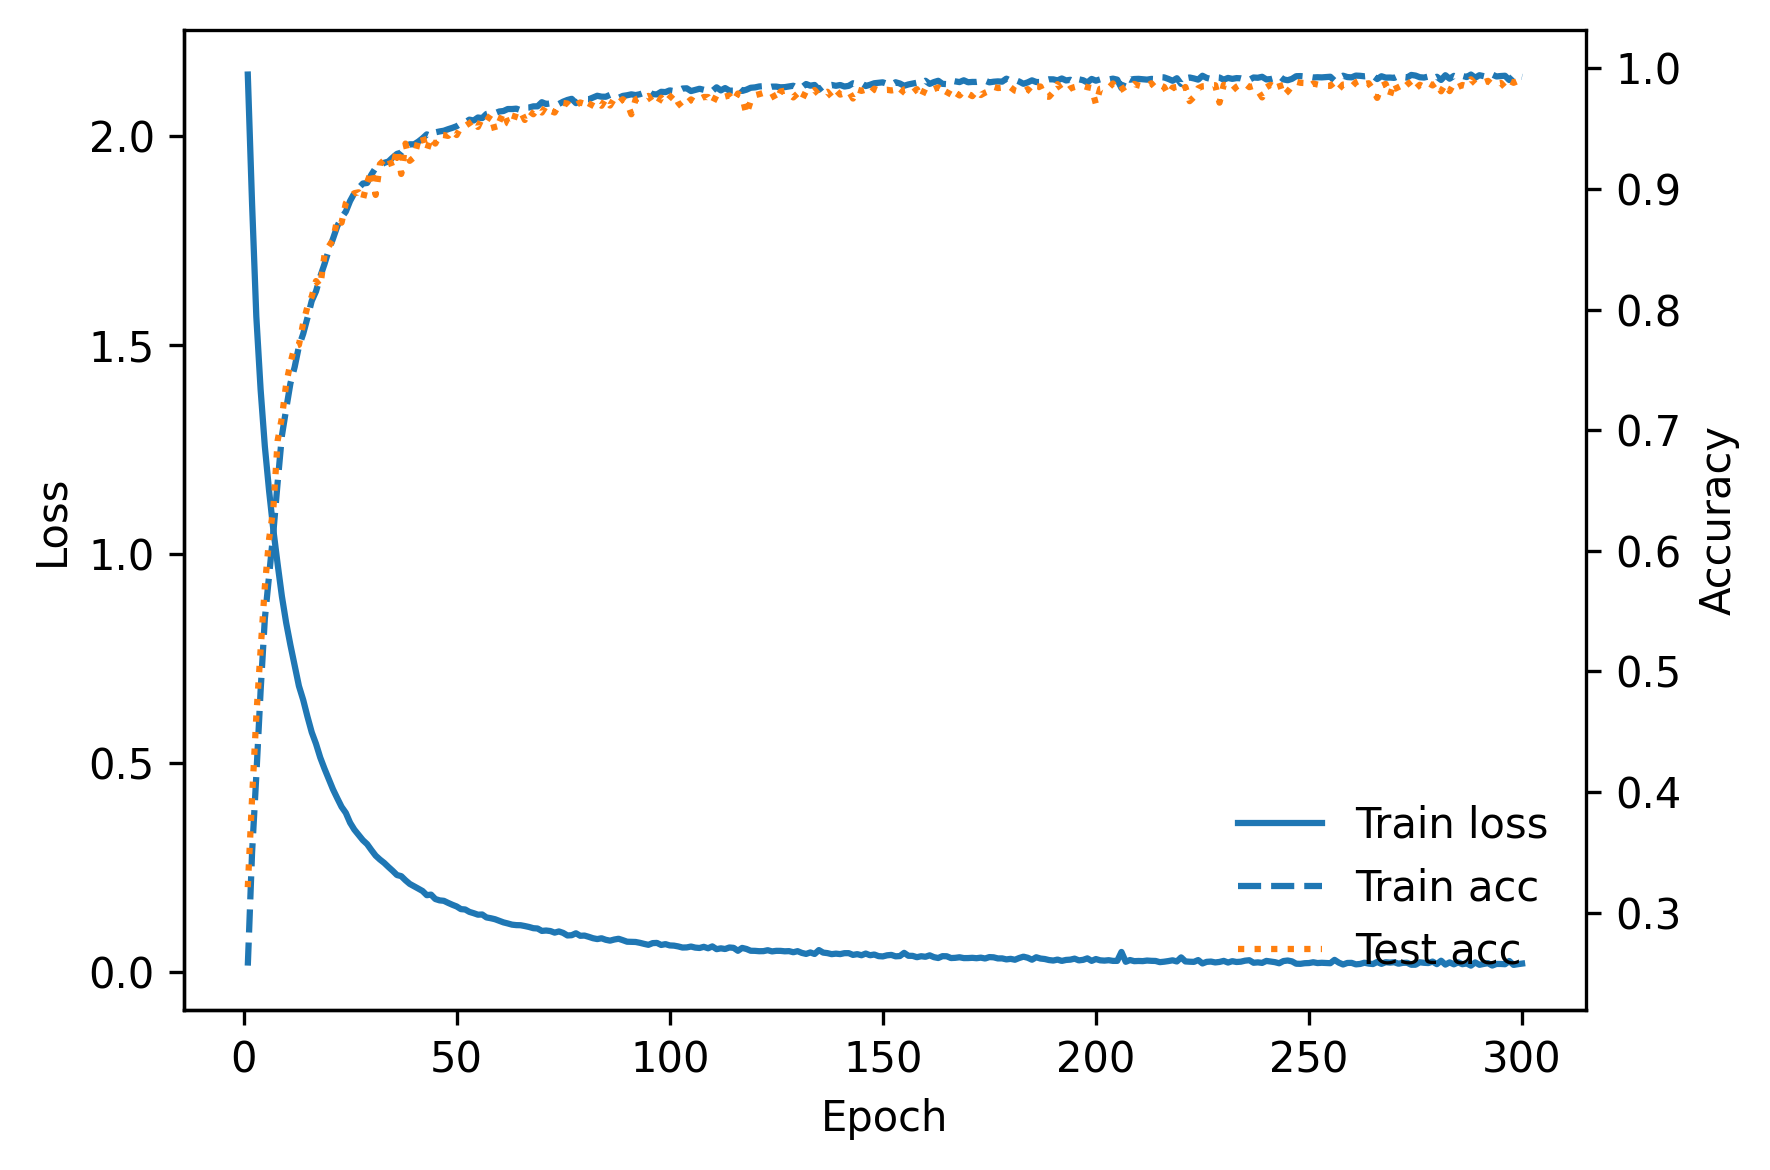

训练集样本： ['X209' 'X285' 'X058' 'X199' 'X059' 'X288' 'X236' 'X234' 'X133' 'X108'
 'X145' 'X159' 'X212' 'X222' 'X297' 'X276' 'X050' 'X158' 'X105' 'X259'
 'X249' 'X283' 'X130' 'X316' 'X312' 'X286' 'X281' 'X275' 'X311' 'X310'
 'X287' 'X261' 'X223' 'X282' 'X298' 'X313' 'X224' 'X186' 'X293' 'X299'
 'X273' 'X188' 'X292' 'X305' 'X132' 'X048' 'X197' 'X160' 'X306' 'X260'
 'X280' 'X057' 'X277' 'X315' 'X185' 'X247' 'X248' 'X210' 'X270' 'X146'
 'X056' 'X131' 'X295' 'X301' 'X198' 'X119' 'X309' 'X170' 'X049' 'X278'
 'X258' 'X156' 'X211' 'X237' 'X300' 'X271' 'X200' 'X291' 'X246' 'X172'
 'X169' 'X120' 'X318']
测试集样本： ['X296' 'X106' 'X284' 'X107' 'X235' 'X121' 'X274' 'X147' 'X225' 'X118'
 'X171' 'X144' 'X187' 'X279' 'X289' 'X302' 'X272' 'X294' 'X307' 'X290'
 'X317']
训练集大小: 21787, 测试集大小: 5796
特征维度: 40
X_train: (21787, 40)
y_train: (21787,)
X_test : (5796, 40)
y_test : (5796,)
DBN input_dim = 40 , n_classes = 11
Pretraining RBM layer 1/2
  Epoch 1/80, recon loss = 0.240075
  Epoch 2/80, recon loss = 0.163314

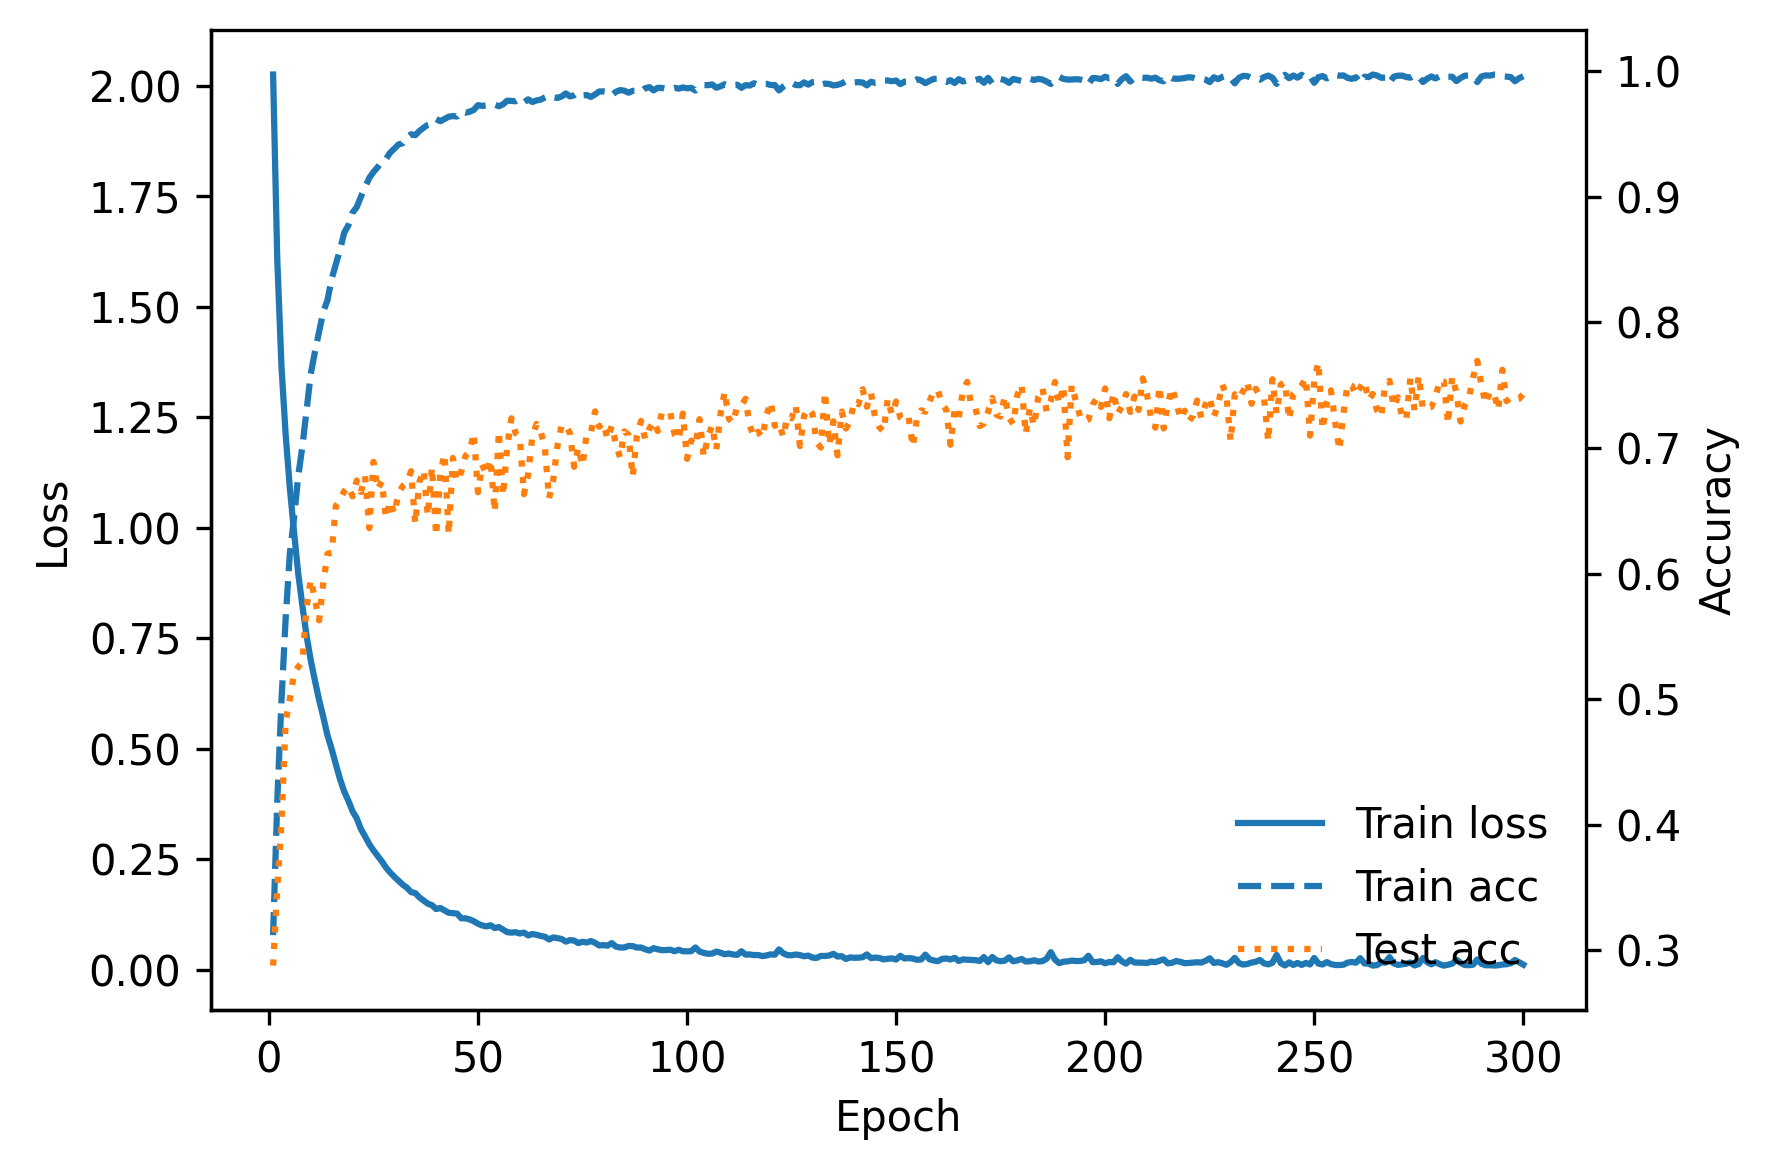

[save_results_df] 结果已保存到：E:\故障诊断2\实验整理\result\df\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_result3.pkl
[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_env_all_feature_models.png


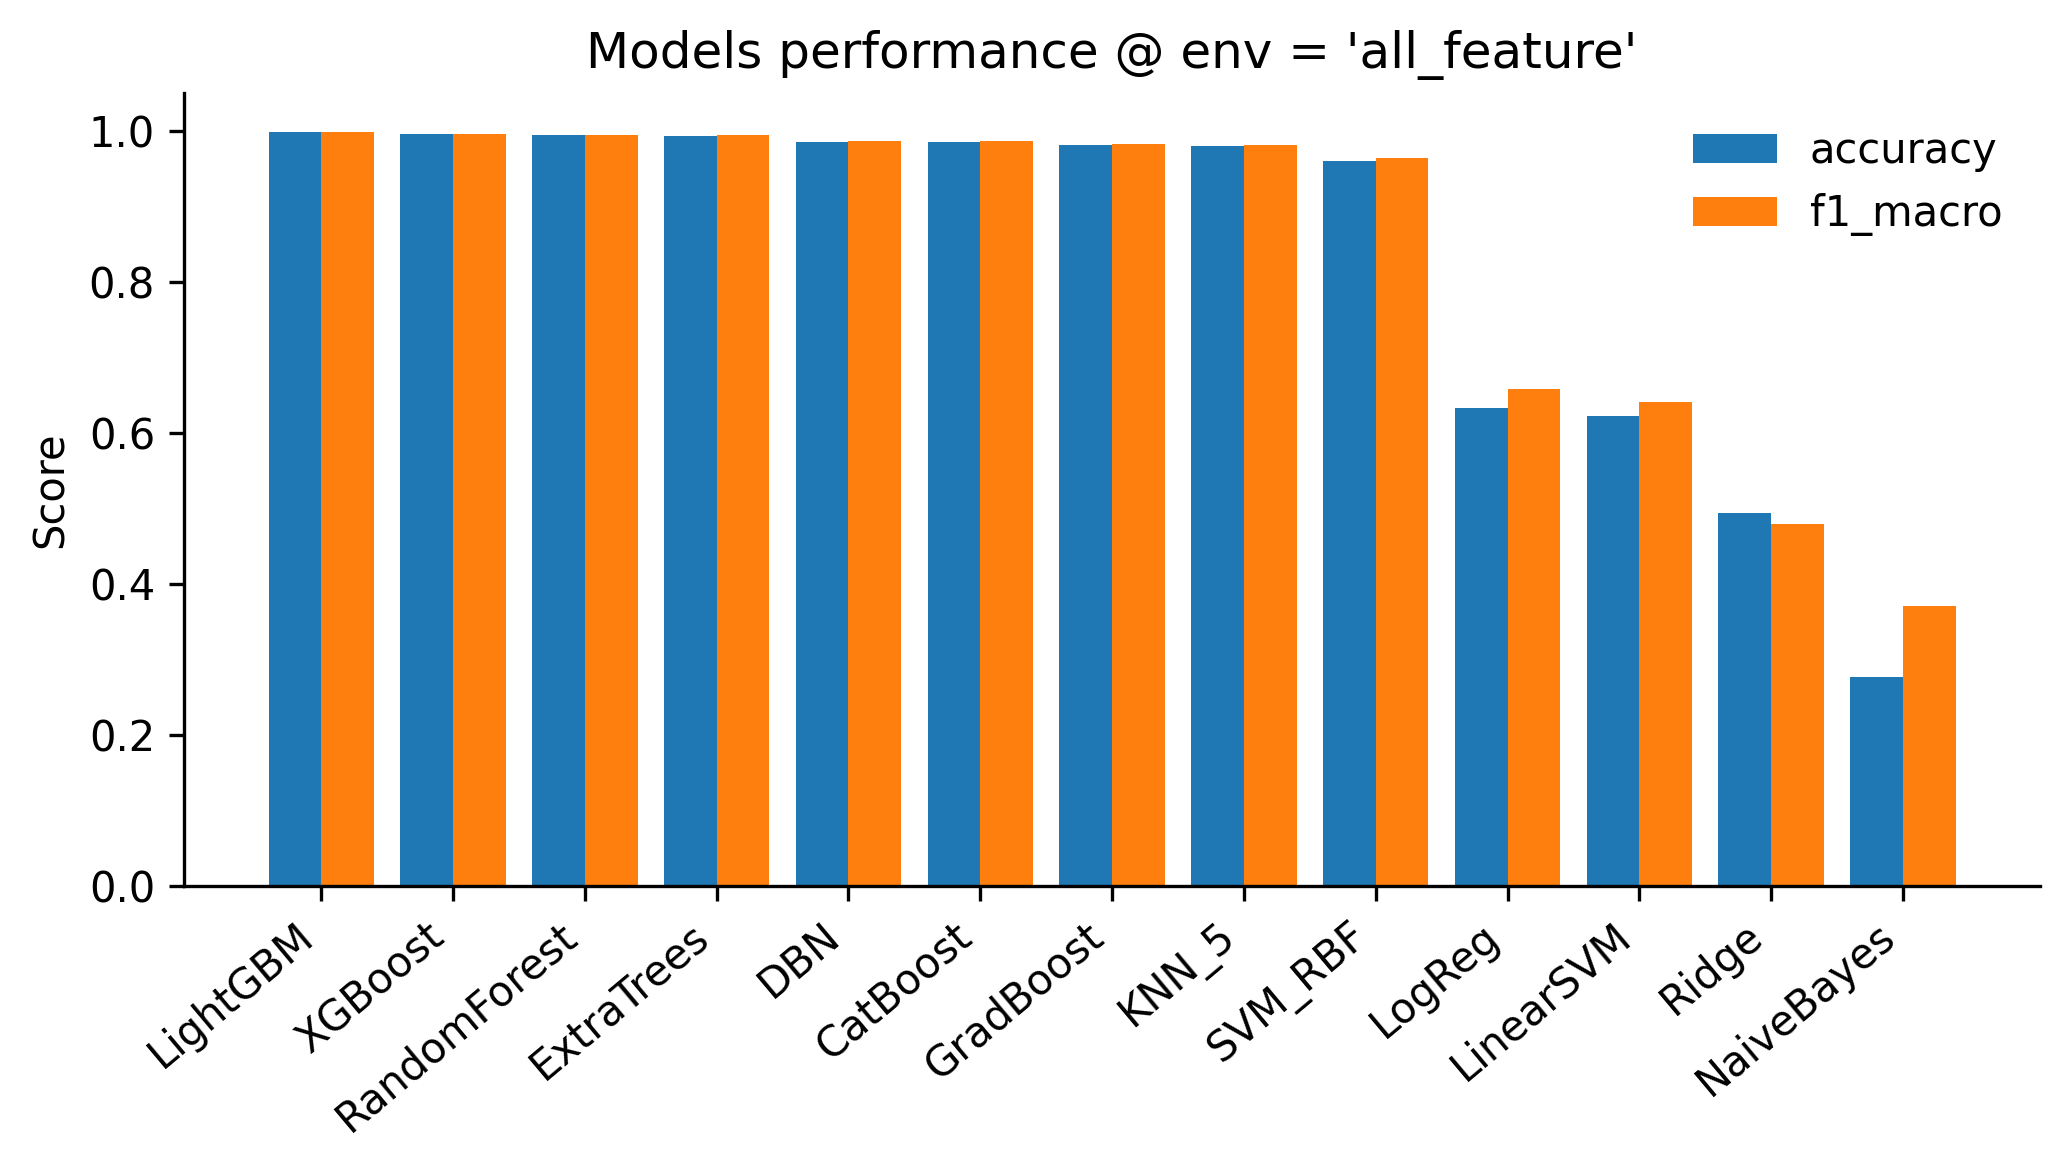

[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_env_all_feature_fc_models.png


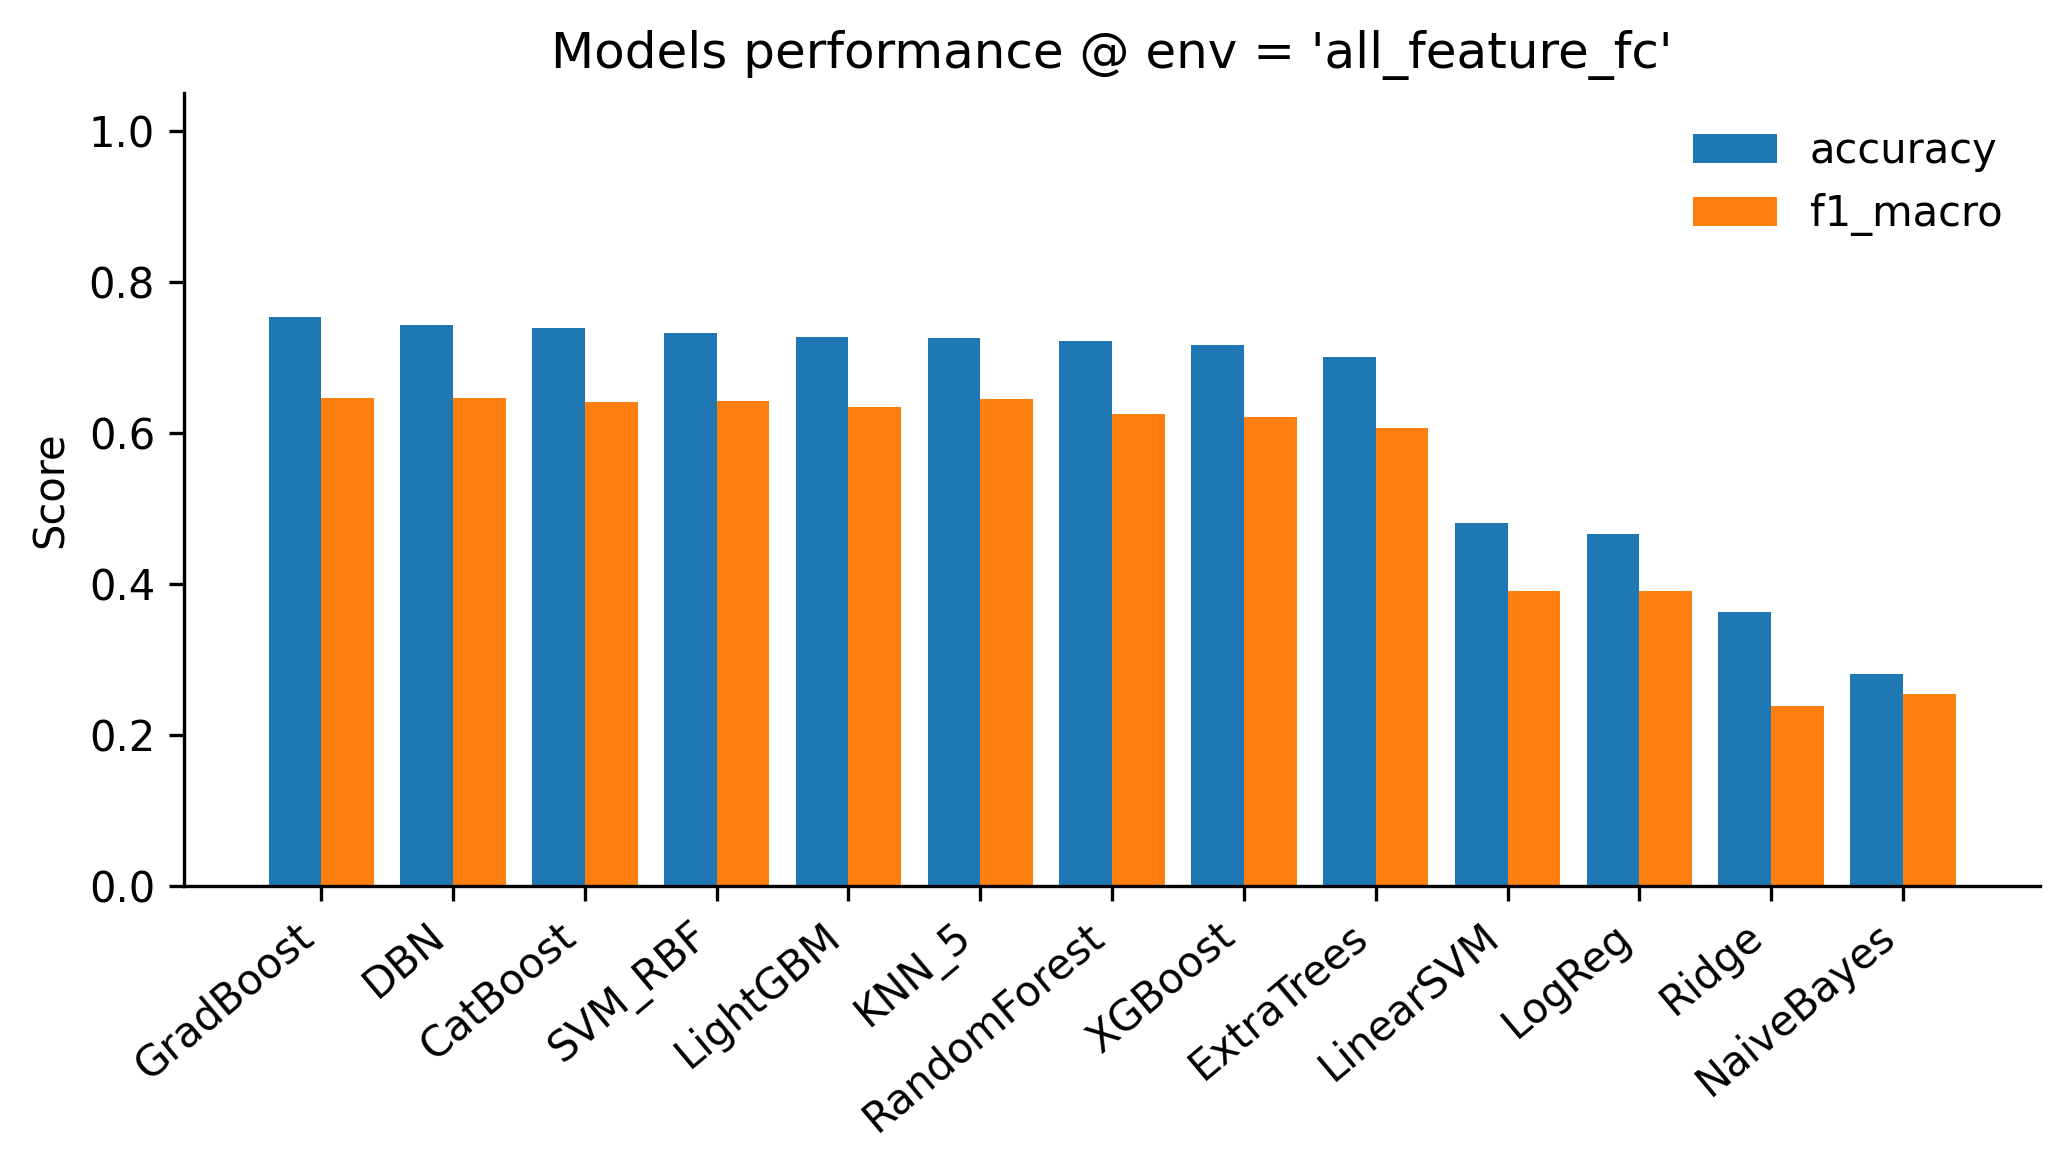

=== 全流程执行完成 ===


In [3]:
CONFIG = {
    "sampling_rates": ['12'],       # None 或 [] 表示不筛选;12,48,好像只能单独选一个
    "sampling_positions": ["DE",'BA','FE'],    
    "bearing_positions": None,       #['FE', 'DE', 'Normal']
    "loads": ['0', '1', '2','3'],    #载荷大小     
    "rpms": None,                    # 不筛选转速
    "fault_types": None,             # 不筛选故障类型
    "or_positons": []                # [None, 'Centered', 'Opposite', 'Orthogonal']
}
#设定数据分区方式
WINDOW_SIZE = 2048
STEP_SIZE = 1024

#保存路径
SAVE_DIR = r'E:\故障诊断2\实验整理\dataset\processed\npz'
CSV_SAVE_DIR =  r'E:\故障诊断2\实验整理\dataset\processed\csv'

RESULT_PATH = r'E:\故障诊断2\实验整理\result\df'
RESULT_PATH_FIG = r'E:\故障诊断2\实验整理\result\figs'

if __name__ == "__main__":
    main_bearing_fault_diagnosis(
        pickle_path='E:\故障诊断2\实验整理\dataset\processed\CWRU_bearing_dataset.pkl',
        save_dir=SAVE_DIR,
        csv_save_dir=CSV_SAVE_DIR,
        result_path=RESULT_PATH,
        result_fig_path=RESULT_PATH_FIG,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE,
        config=CONFIG
    )
    print("=== 全流程执行完成 ===")

筛选后样本数： 202
条件名称： cond_sampling_rates_12_sampling_positions_DE-BA_loads_0-1-2-3
X shape: (18634, 2048)
y shape: (18634,)
npz 文件已保存到: E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA_loads_0-1-2-3_win2048_step1024.npz
12000
(18634, 2048) (18634,) (18634,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
csv文件已保存为 cond_sampling_rates_12_sampling_positions_DE-BA_loads_0-1-2-3_win2048_step1024.csv
训练集大小: 14907, 测试集大小: 3727
特征维度: 40

训练模型: LogReg


d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg - Accuracy: 0.7282, F1_macro: 0.7372
分类报告:
              precision    recall  f1-score   support

           0     0.4980    0.4241    0.4581       290
           1     0.6736    0.5876    0.6277       274
           2     0.5526    0.2800    0.3717       300
           3     1.0000    0.9898    0.9949        98
           4     0.8606    0.8885    0.8743       278
           5     0.7810    0.8270    0.8034       289
           6     0.7119    0.7241    0.7179       290
           7     1.0000    1.0000    1.0000        80
           8     0.6981    0.8575    0.7696       898
           9     0.6284    0.7262    0.6738       347
          10     0.8673    0.7736    0.8178       583

    accuracy                         0.7282      3727
   macro avg     0.7520    0.7344    0.7372      3727
weighted avg     0.7230    0.7282    0.7188      3727

混淆矩阵:
[[123  14  15   0   3  16   4   0  91  14  10]
 [  5 161   3   0   5  11  19   0  48   5  17]
 [ 54  21  84   0   4   1  10   0  83

Exception in thread Thread-145 (_readerthread):
Traceback (most recent call last):
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\anaconda\envs\pikaqiu\Lib\site-packages\ipykernel\ipkernel.py", line 788, in run_closure
    _threading_Thread_run(self)
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anaconda\envs\pikaqiu\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


KNN_5 - Accuracy: 0.9775, F1_macro: 0.9778
分类报告:
              precision    recall  f1-score   support

           0     0.9757    0.9690    0.9723       290
           1     0.9492    0.8869    0.9170       274
           2     0.9521    0.9267    0.9392       300
           3     1.0000    1.0000    1.0000        98
           4     0.9786    0.9892    0.9839       278
           5     0.9897    0.9931    0.9914       289
           6     0.9932    1.0000    0.9966       290
           7     1.0000    1.0000    1.0000        80
           8     0.9738    0.9922    0.9829       898
           9     0.9855    0.9827    0.9841       347
          10     0.9830    0.9931    0.9881       583

    accuracy                         0.9775      3727
   macro avg     0.9801    0.9757    0.9778      3727
weighted avg     0.9773    0.9775    0.9772      3727

混淆矩阵:
[[281   1   5   0   0   0   1   0   1   0   1]
 [  3 243   3   0   3   0   0   0  17   0   5]
 [  3   7 278   0   0   2   0   0   6 

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

LightGBM - Accuracy: 0.7376, F1_macro: 0.6206
分类报告:
              precision    recall  f1-score   support

           0     0.7280    0.6594    0.6920       552
           1     0.6934    0.9647    0.8068       368
           2     0.2193    0.1114    0.1477       368
           4     0.9465    0.8333    0.8863       552
           5     1.0000    0.6114    0.7589       368
           6     0.6583    0.9946    0.7922       184
           8     0.7726    0.9203    0.8400      1104
           9     0.0000    0.0000    0.0000         0
          10     0.8078    0.5598    0.6613       368

    accuracy                         0.7376      3864
   macro avg     0.6473    0.6283    0.6206      3864
weighted avg     0.7504    0.7376    0.7294      3864

混淆矩阵:
[[ 364   39  146    0    0    0    0    3    0]
 [   0  355    0    5    0    0    8    0    0]
 [  66  112   41    0    0    0  146    0    3]
 [   0    0    0  460    0    0    0   92    0]
 [   3    0    0    0  225   95   34   11    

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  Epoch 1/50, recon loss = 0.268557
  Epoch 2/50, recon loss = 0.180174
  Epoch 3/50, recon loss = 0.159662
  Epoch 4/50, recon loss = 0.151505
  Epoch 5/50, recon loss = 0.148124
  Epoch 6/50, recon loss = 0.145831
  Epoch 7/50, recon loss = 0.144293
  Epoch 8/50, recon loss = 0.144441
  Epoch 9/50, recon loss = 0.142434
  Epoch 10/50, recon loss = 0.143327
  Epoch 11/50, recon loss = 0.142701
  Epoch 12/50, recon loss = 0.142746
  Epoch 13/50, recon loss = 0.141900
  Epoch 14/50, recon loss = 0.141850
  Epoch 15/50, recon loss = 0.141826
  Epoch 16/50, recon loss = 0.141545
  Epoch 17/50, recon loss = 0.142156
  Epoch 18/50, recon loss = 0.141583
  Epoch 19/50, recon loss = 0.142295
  Epoch 20/50, recon loss = 0.142092
  Epoch 21/50, recon loss = 0.141388
  Epoch 22/50, recon loss = 0.141752
  Epoch 23/50, recon loss = 0.142081
  Epoch 24/50, recon loss = 0.141313
  Epoch 25/50, recon loss = 0.141539
  Epoch 26/50, recon loss = 0.141694
  Epoch 27/50, recon loss = 0.141462
  Epoch 28

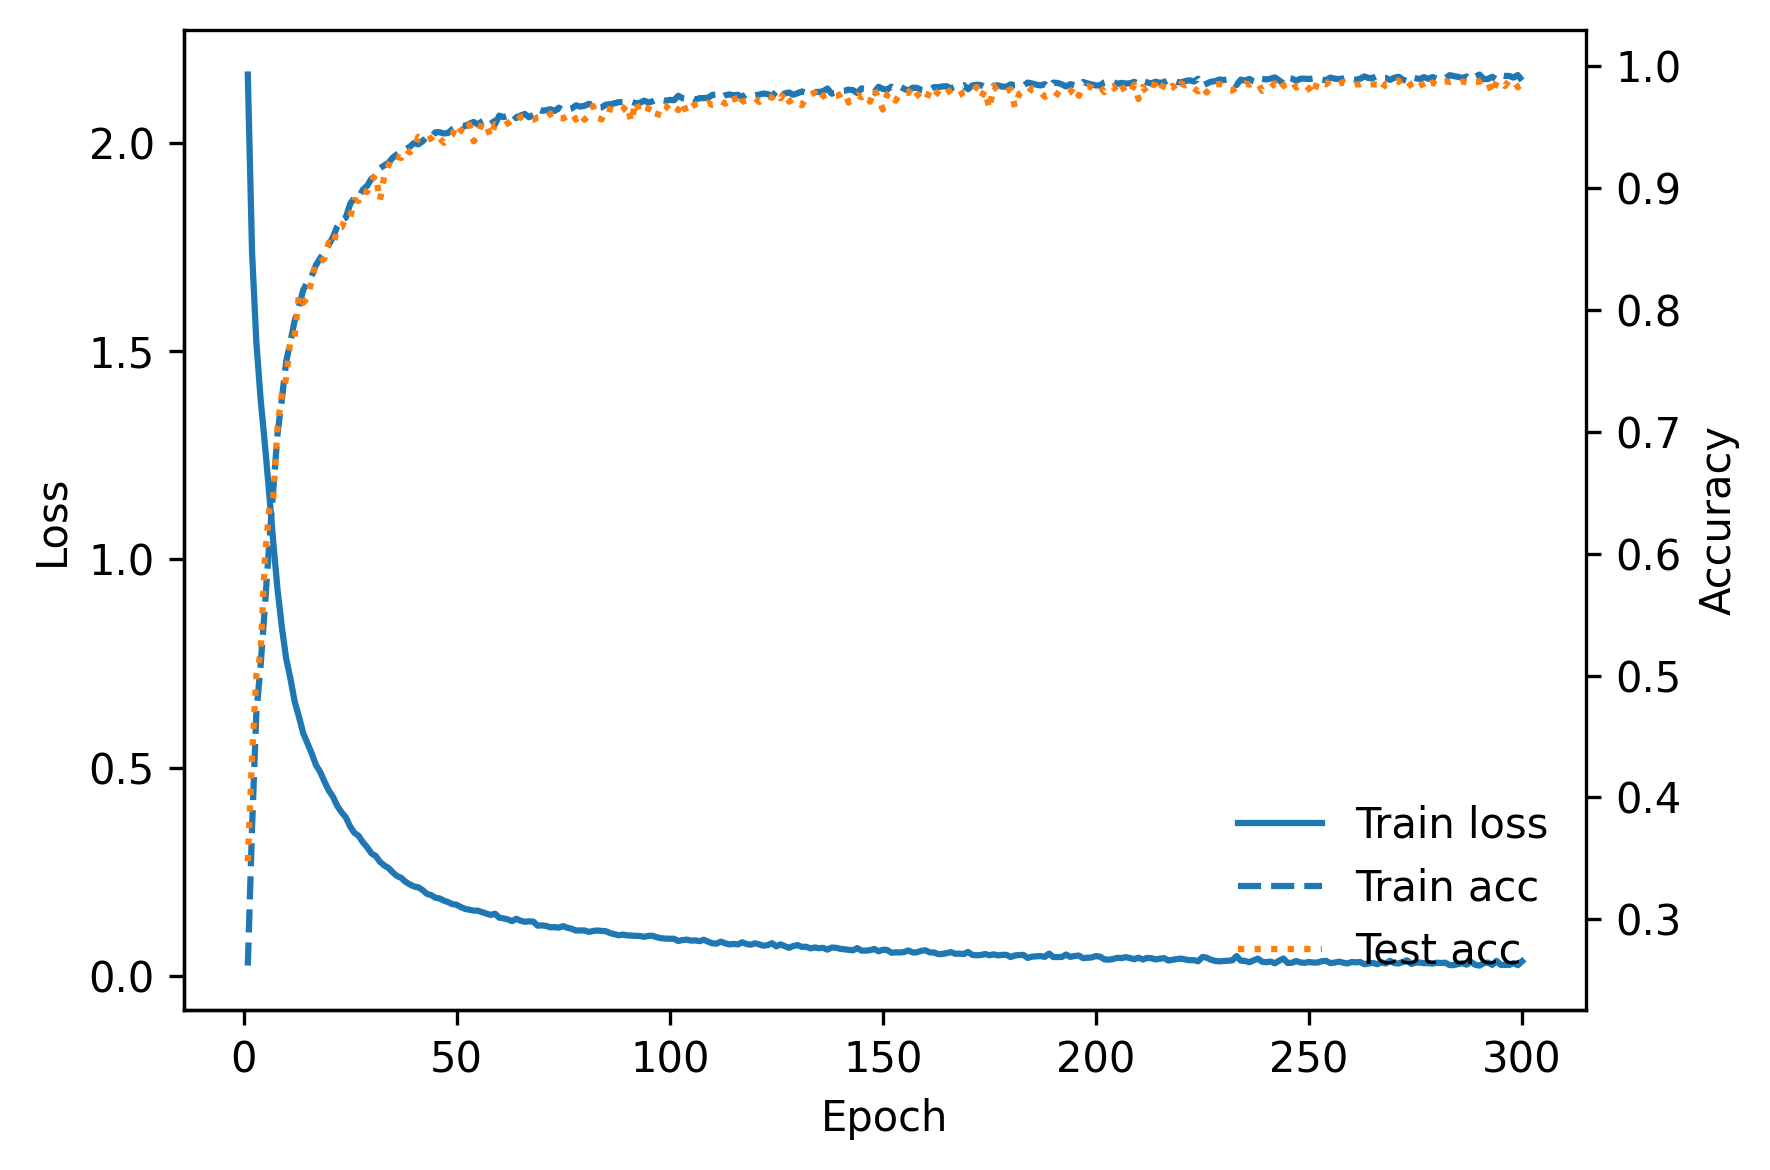

训练集样本： ['X209' 'X285' 'X058' 'X199' 'X059' 'X288' 'X236' 'X234' 'X133' 'X108'
 'X145' 'X159' 'X212' 'X222' 'X297' 'X276' 'X050' 'X158' 'X105' 'X259'
 'X249' 'X283' 'X130' 'X316' 'X312' 'X286' 'X281' 'X275' 'X311' 'X310'
 'X287' 'X261' 'X223' 'X282' 'X298' 'X313' 'X224' 'X186' 'X293' 'X299'
 'X273' 'X188' 'X292' 'X305' 'X132' 'X048' 'X197' 'X160' 'X306' 'X260'
 'X280' 'X057' 'X277' 'X315' 'X185' 'X247' 'X248' 'X210' 'X270' 'X146'
 'X056' 'X131' 'X295' 'X301' 'X198' 'X119' 'X309' 'X170' 'X049' 'X278'
 'X258' 'X156' 'X211' 'X237' 'X300' 'X271' 'X200' 'X291' 'X246' 'X172'
 'X169' 'X120' 'X318']
测试集样本： ['X296' 'X106' 'X284' 'X107' 'X235' 'X121' 'X274' 'X147' 'X225' 'X118'
 'X171' 'X144' 'X187' 'X279' 'X289' 'X302' 'X272' 'X294' 'X307' 'X290'
 'X317']
训练集大小: 14770, 测试集大小: 3864
特征维度: 40
X_train: (14770, 40)
y_train: (14770,)
X_test : (3864, 40)
y_test : (3864,)
DBN input_dim = 40 , n_classes = 11
Pretraining RBM layer 1/2
  Epoch 1/80, recon loss = 0.270368
  Epoch 2/80, recon loss = 0.184754

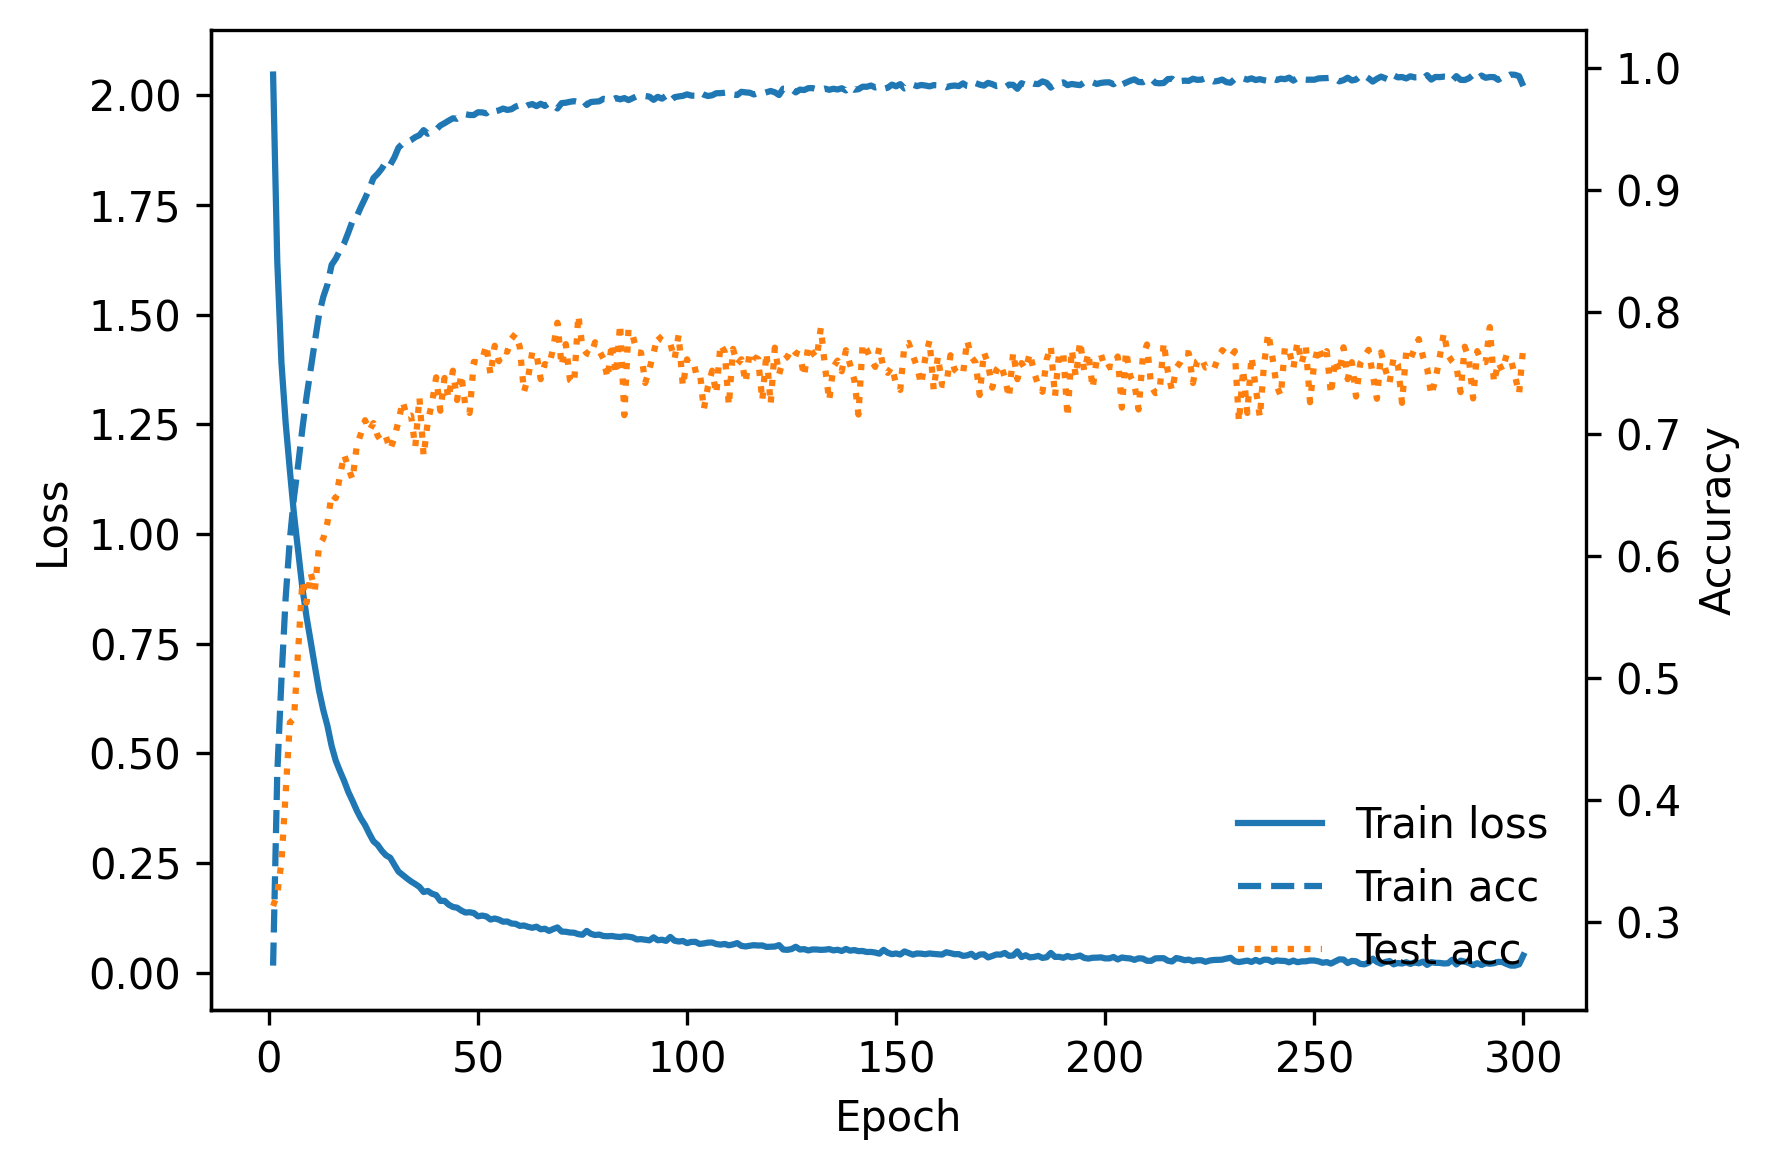

[save_results_df] 结果已保存到：E:\故障诊断2\实验整理\result\df\cond_sampling_rates_12_sampling_positions_DE-BA_loads_0-1-2-3_win2048_step1024_result1.pkl
[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_12_sampling_positions_DE-BA_loads_0-1-2-3_win2048_step1024_env_all_feature_models.png


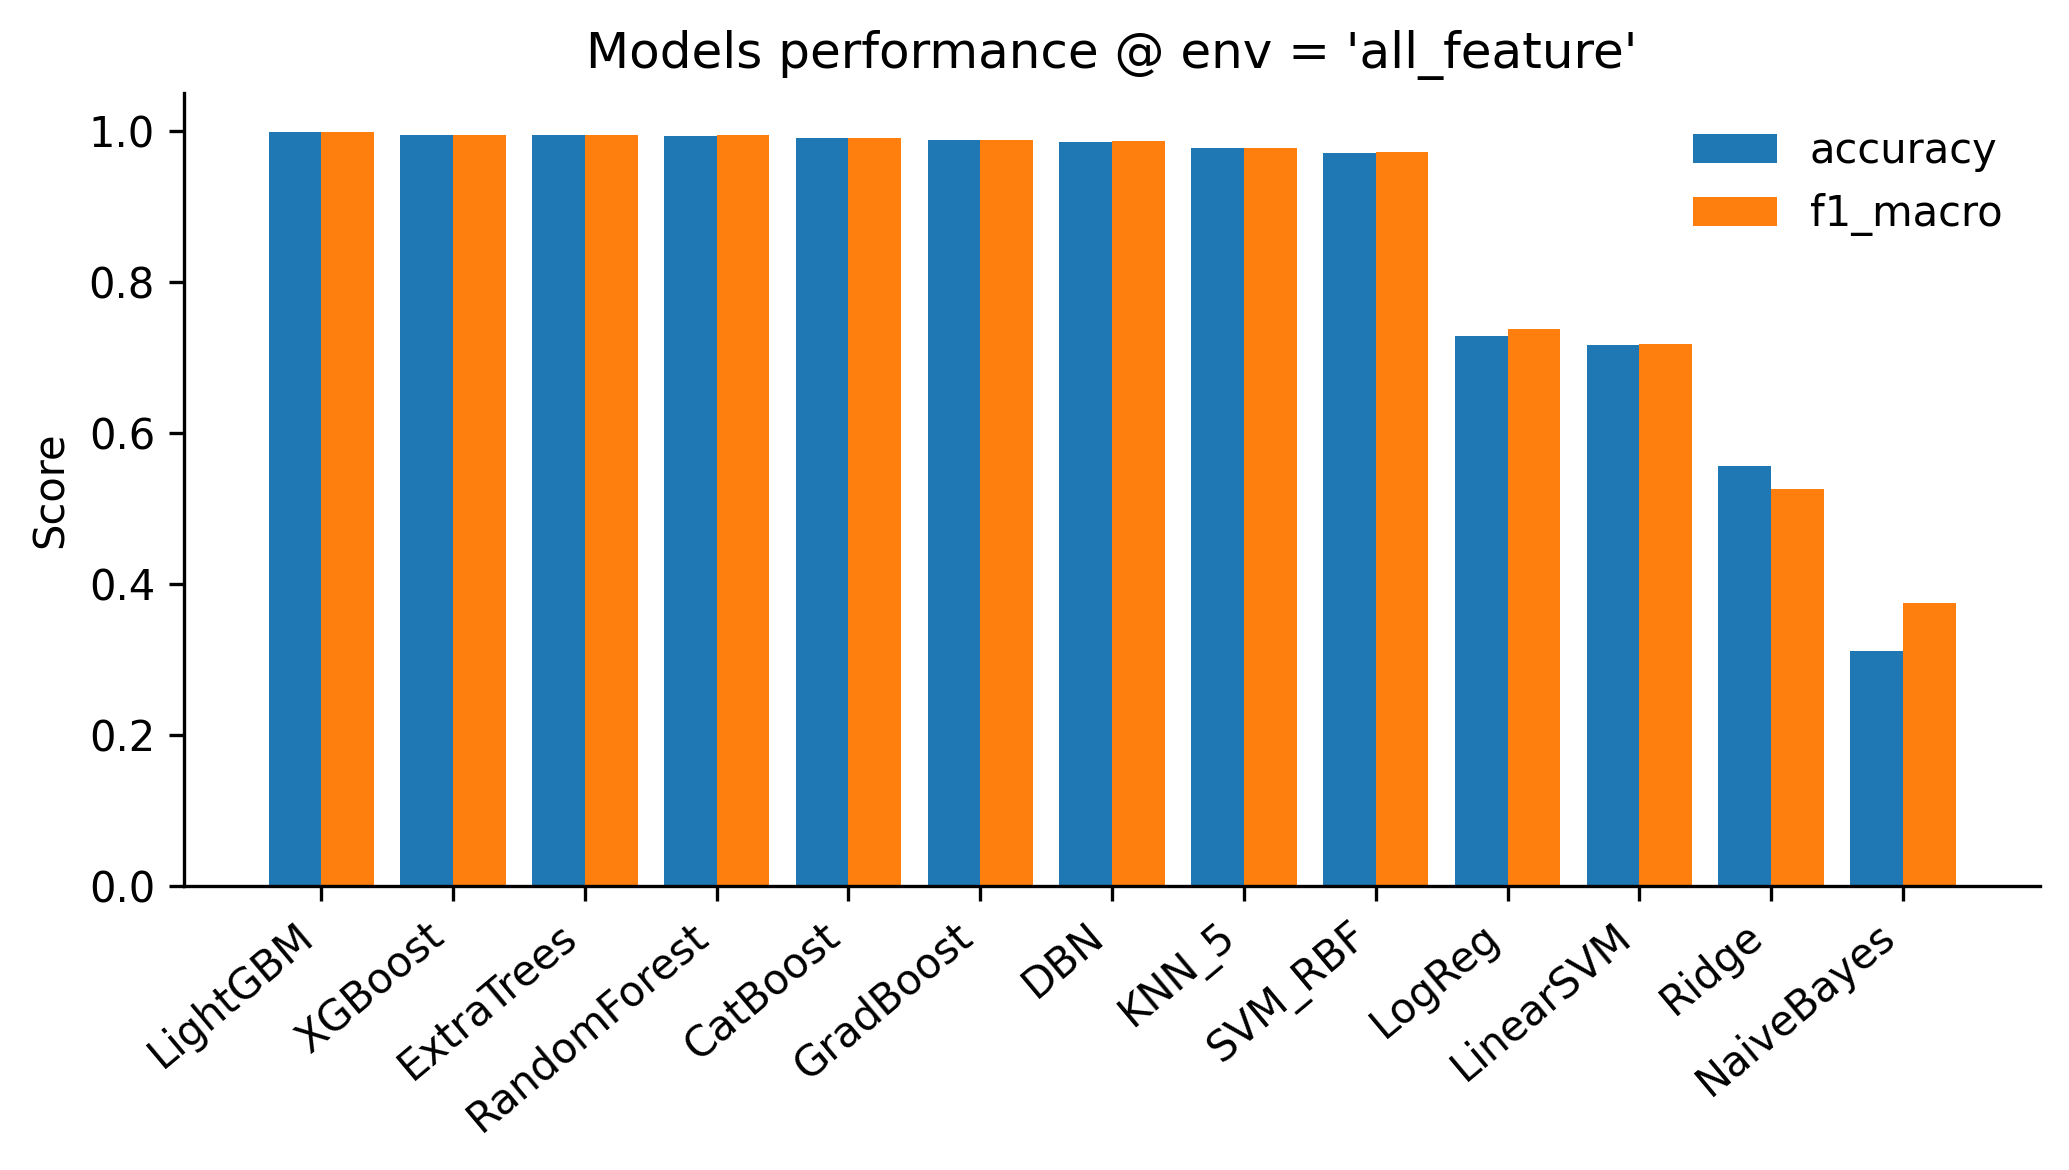

[plot_models_for_env] 图已保存到：E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_12_sampling_positions_DE-BA_loads_0-1-2-3_win2048_step1024_env_all_feature_fc_models.png


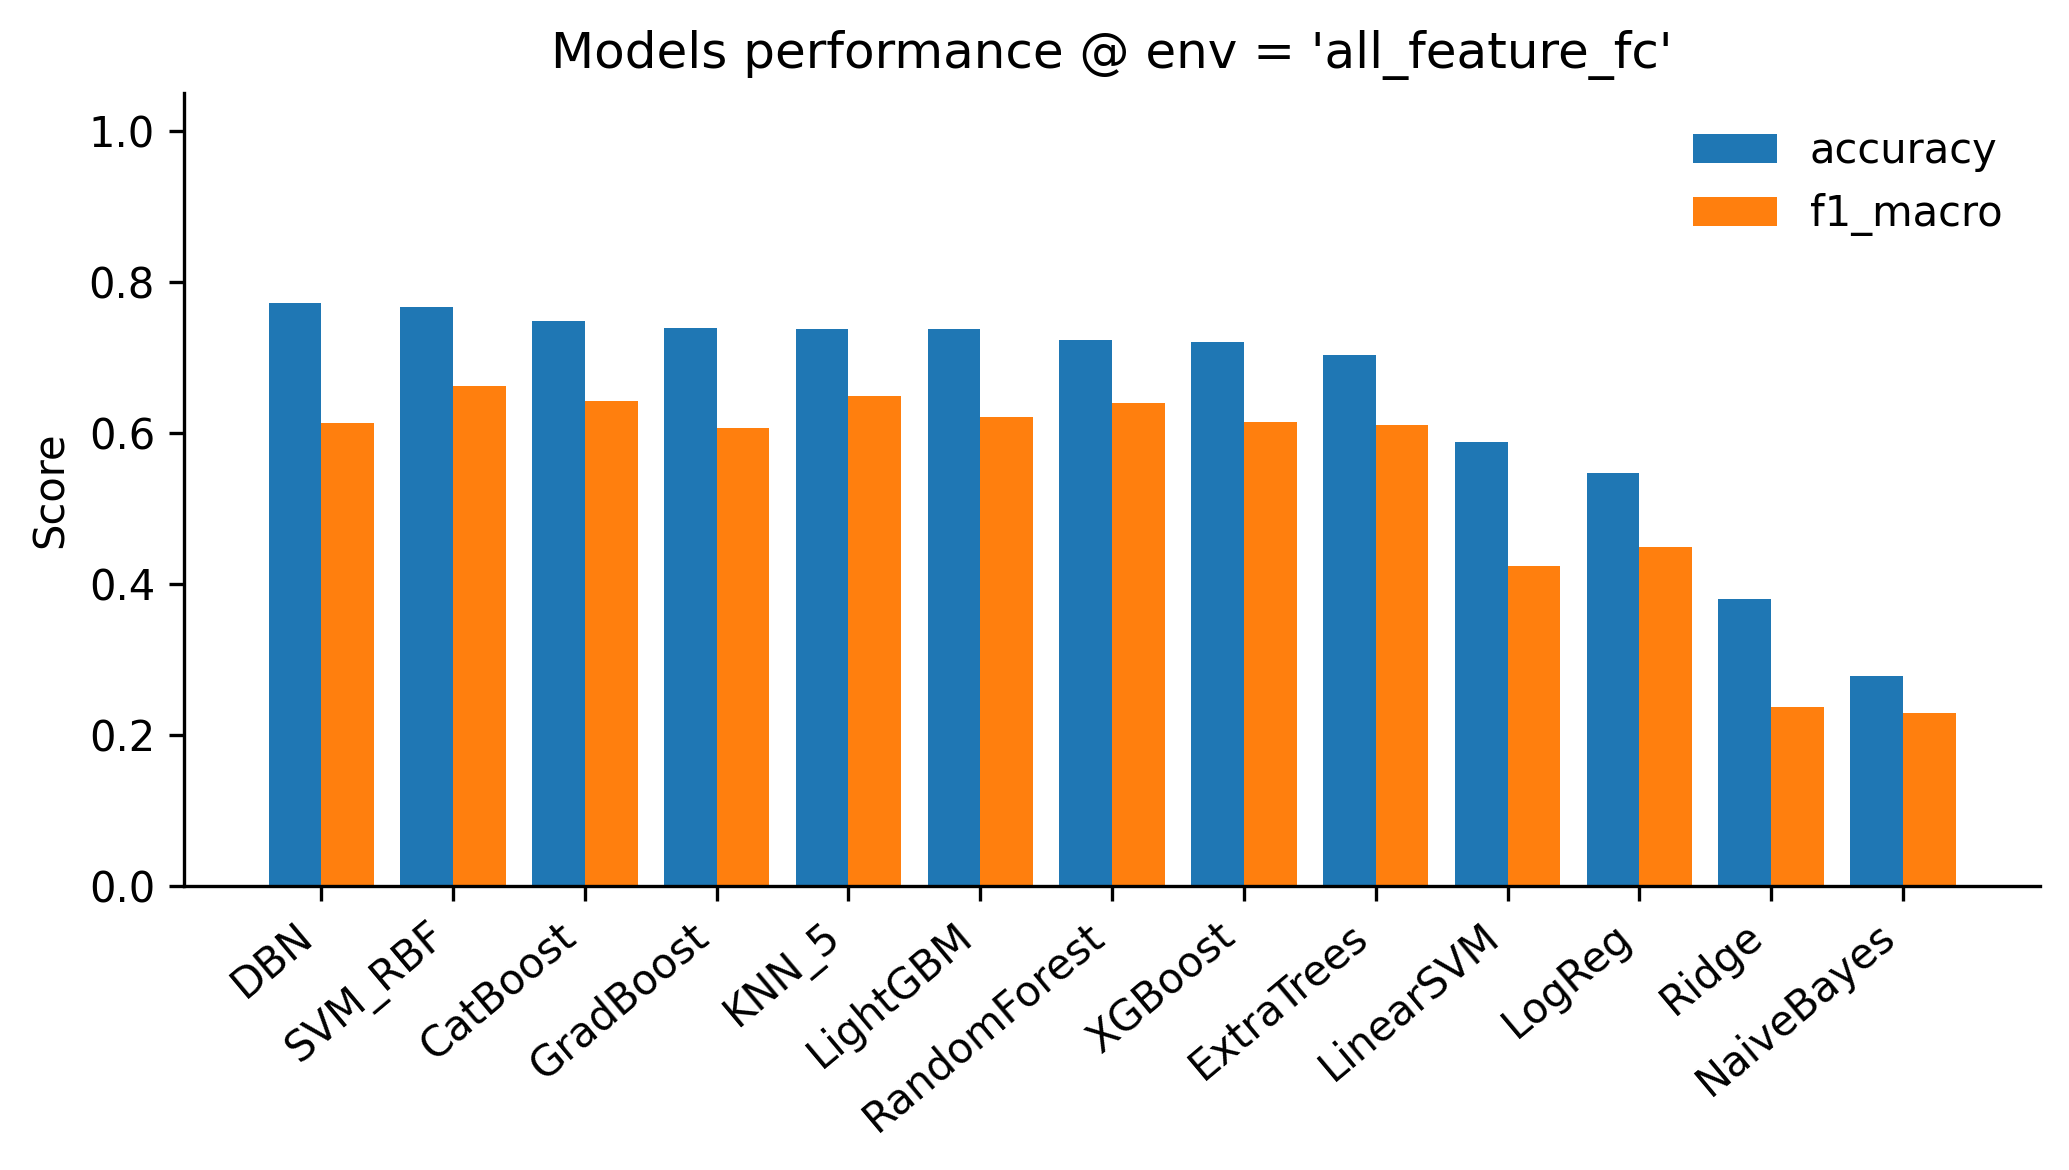

=== 全流程执行完成 ===


In [3]:
CONFIG = {
    "sampling_rates": ['12'],       # None 或 [] 表示不筛选;12,48,好像只能单独选一个
    "sampling_positions": ["DE",'BA'], #不要FE试一试    
    "bearing_positions": None,       #['FE', 'DE', 'Normal']
    "loads": ['0', '1', '2','3'],    #载荷大小     
    "rpms": None,                    # 不筛选转速
    "fault_types": None,             # 不筛选故障类型
    "or_positons": []                # [None, 'Centered', 'Opposite', 'Orthogonal']
}
#设定数据分区方式
WINDOW_SIZE = 2048
STEP_SIZE = 1024

#保存路径
SAVE_DIR = r'E:\故障诊断2\实验整理\dataset\processed\npz'
CSV_SAVE_DIR =  r'E:\故障诊断2\实验整理\dataset\processed\csv'

RESULT_PATH = r'E:\故障诊断2\实验整理\result\df'
RESULT_PATH_FIG = r'E:\故障诊断2\实验整理\result\figs'

if __name__ == "__main__":
    main_bearing_fault_diagnosis(
        pickle_path='E:\故障诊断2\实验整理\dataset\processed\CWRU_bearing_dataset.pkl',
        save_dir=SAVE_DIR,
        csv_save_dir=CSV_SAVE_DIR,
        result_path=RESULT_PATH,
        result_fig_path=RESULT_PATH_FIG,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE,
        config=CONFIG
    )
    print("=== 全流程执行完成 ===")

In [3]:
df = pd.read_pickle(r'E:\故障诊断2\实验整理\result\df\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_result3.pkl')
df2 = pd.read_pickle(r'E:\故障诊断2\实验整理\result\df\cond_sampling_rates_12_sampling_positions_DE-BA_loads_0-1-2-3_win2048_step1024_result1.pkl')

In [4]:
df

accuracy  f1_macro
env            model                           
all_feature    LightGBM      0.998550  0.998756
               XGBoost       0.995469  0.995833
               RandomForest  0.994200  0.994597
               ExtraTrees    0.993293  0.993890
               DBN           0.985137  0.986725
               CatBoost      0.984774  0.986523
               GradBoost     0.981512  0.982830
               KNN_5         0.980243  0.980686
               SVM_RBF       0.959942  0.963790
               LogReg        0.632228  0.658269
               LinearSVM     0.622440  0.640842
               Ridge         0.494109  0.479135
               NaiveBayes    0.276237  0.370910
all_feature_fc GradBoost     0.753278  0.646008
               DBN           0.742926  0.646320
               CatBoost      0.738958  0.640555
               SVM_RBF       0.732229  0.641589
               LightGBM      0.727053  0.633503
               KNN_5         0.724983  0.644821
               RandomForest  0.721360  0.625087
               XGBoost       0.716184  0.621063
               ExtraTrees    0.700828  0.606365
               LinearSVM     0.481021  0.390923
               LogReg        0.465666  0.390370
               Ridge         0.362491  0.237466
               NaiveBayes    0.280021  0.254597

In [7]:
df2

accuracy  f1_macro
env            model                           
all_feature    LightGBM      0.997854  0.998207
               XGBoost       0.994634  0.994626
               ExtraTrees    0.994097  0.994189
               RandomForest  0.993561  0.993967
               CatBoost      0.990341  0.990546
               GradBoost     0.987658  0.988366
               DBN           0.985243  0.986467
               KNN_5         0.977462  0.977764
               SVM_RBF       0.971022  0.972066
               LogReg        0.728200  0.737197
               LinearSVM     0.715857  0.717251
               Ridge         0.555675  0.525857
               NaiveBayes    0.310706  0.374800
all_feature_fc DBN           0.771739  0.613497
               SVM_RBF       0.766563  0.661758
               CatBoost      0.748447  0.641533
               GradBoost     0.739130  0.606576
               KNN_5         0.737578  0.649112
               LightGBM      0.737578  0.620588
               RandomForest  0.723085  0.639243
               XGBoost       0.720756  0.614112
               ExtraTrees    0.703157  0.610643
               LinearSVM     0.587474  0.423402
               LogReg        0.546843  0.448204
               Ridge         0.380435  0.236488
               NaiveBayes    0.277692  0.228287

In [6]:
df

accuracy  f1_macro
env            model                           
all_feature    LightGBM      0.997854  0.998207
               XGBoost       0.994634  0.994626
               ExtraTrees    0.994097  0.994189
               RandomForest  0.993561  0.993967
               CatBoost      0.990341  0.990546
               GradBoost     0.987658  0.988366
               DBN           0.985243  0.986467
               KNN_5         0.977462  0.977764
               SVM_RBF       0.971022  0.972066
               LogReg        0.728200  0.737197
               LinearSVM     0.715857  0.717251
               Ridge         0.555675  0.525857
               NaiveBayes    0.310706  0.374800
all_feature_fc DBN           0.771739  0.613497
               SVM_RBF       0.766563  0.661758
               CatBoost      0.748447  0.641533
               GradBoost     0.739130  0.606576
               KNN_5         0.737578  0.649112
               LightGBM      0.737578  0.620588
               RandomForest  0.723085  0.639243
               XGBoost       0.720756  0.614112
               ExtraTrees    0.703157  0.610643
               LinearSVM     0.587474  0.423402
               LogReg        0.546843  0.448204
               Ridge         0.380435  0.236488
               NaiveBayes    0.277692  0.228287